## **TEAM 1**: Final Analysis Pipeline

### SBA 7(a) Loans

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import os

from google.colab import drive


In [ ]:
# mount drive
drive.mount('/content/drive')
path_gdrive = "/content/drive/Shareddrives/TEAM 1 Statistical Models for Data Science/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


*data can be found: https://data.sba.gov/en/dataset/7-a-504-foia*

In [ ]:
# detect the data files for the 7(a) loans
data_files = glob(os.path.join(path_gdrive,"foia-7a*.csv"))
display(data_files)

['/content/drive/Shareddrives/TEAM 1 Statistical Models for Data Science/foia-7a-fy1991-fy1999-asof-250930.csv',
 '/content/drive/Shareddrives/TEAM 1 Statistical Models for Data Science/foia-7a-fy2000-fy2009-asof-250930.csv',
 '/content/drive/Shareddrives/TEAM 1 Statistical Models for Data Science/foia-7a-fy2010-fy2019-asof-250930.csv',
 '/content/drive/Shareddrives/TEAM 1 Statistical Models for Data Science/foia-7a-fy2020-present-asof-250930.csv']

In [ ]:
loans = pd.DataFrame()
for data_file in data_files:
  data = pd.read_csv(data_file)
  loans = pd.concat([loans,data])
display(loans.head(5))

/tmp/ipython-input-2439450738.py:3: DtypeWarning: Columns (7,10,14,27) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_file)
/tmp/ipython-input-2439450738.py:3: DtypeWarning: Columns (14,23,27) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_file)
/tmp/ipython-input-2439450738.py:3: DtypeWarning: Columns (14,34) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_file)
/tmp/ipython-input-2439450738.py:3: DtypeWarning: Columns (36,37,42) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_file)


,AsOfDate,Program,BorrName,BorrStreet,BorrCity,BorrState,BorrZip,LocationID,BankName,BankFDICNumber,...,BusinessType,BusinessAge,LoanStatus,PaidinFullDate,ChargeoffDate,GrossChargeoffAmount,RevolverStatus,JobsSupported,CollateralInd,SoldSecondMarketInd
0,9/30/2025,7A,O'NEILL'S UPHOLSTERY,1500 ST. LOUIS,SPRINGFIELD,MO,65806,53803.0,"U.S. Bank, National Association",6548.0,...,INDIVIDUAL,NaN,PIF,7/31/2005,NaN,0.0,0,0.0,NaN,NaN
1,9/30/2025,7A,K AND K INCORPORATED,11636 SE 5TH,BELLEVUE,WA,98005,9551.0,"Bank of America, National Association",3510.0,...,CORPORATION,NaN,CANCLD,NaN,NaN,0.0,0,0.0,NaN,NaN
2,9/30/2025,7A,INTELLISYS INC.,4641 CROSS ROADS PARK DRIVE,LIVERPOOL,NY,13088,46391.0,Manufacturers and Traders Trust Company,588.0,...,CORPORATION,NaN,PIF,7/31/2005,NaN,0.0,0,0.0,NaN,NaN
3,9/30/2025,7A,ROOFING CONTRACTORS INC.,"2221 DEVONSHIRE ROAD, N.W.",CANTON,OH,44708,57328.0,The Huntington National Bank,6560.0,...,CORPORATION,NaN,CANCLD,NaN,NaN,0.0,0,0.0,NaN,NaN
4,9/30/2025,7A,CHUCK ROAST EQUIPMENT INC.,ODELL HILL ROAD,CONWAY,NH,3818,29633.0,Camden National Bank,4255.0,...,CORPORATION,NaN,PIF,6/30/2006,NaN,0.0,0,0.0,NaN,Y


In [ ]:
display(loans.columns)

Index(['AsOfDate', 'Program', 'BorrName', 'BorrStreet', 'BorrCity',
       'BorrState', 'BorrZip', 'LocationID', 'BankName', 'BankFDICNumber',
       'BankNCUANumber', 'BankStreet', 'BankCity', 'BankState', 'BankZip',
       'GrossApproval', 'SBAGuaranteedApproval', 'ApprovalDate', 'ApprovalFY',
       'FirstDisbursementDate', 'ProcessingMethod', 'Subprogram',
       'InitialInterestRate', 'FixedorVariableInterestRate', 'TerminMonths',
       'NAICSCode', 'NAICSDescription', 'FranchiseCode', 'FranchiseName',
       'ProjectCounty', 'ProjectState', 'SBADistrictOffice',
       'CongressionalDistrict', 'BusinessType', 'BusinessAge', 'LoanStatus',
       'PaidinFullDate', 'ChargeoffDate', 'GrossChargeoffAmount',
       'RevolverStatus', 'JobsSupported', 'CollateralInd',
       'SoldSecondMarketInd'],
      dtype='object')

In [ ]:
loans.describe().T

,count,mean,std,min,25%,50%,75%,max
BorrZip,1902187.0,51919.777398,31261.736064,0.0,23236.00,52748.0,80304.0,99999.00
BankFDICNumber,1714570.0,16321.187040,17036.726695,14.0,3511.00,8273.0,24045.0,91359.00
GrossApproval,1902182.0,302454.907758,569683.267963,-120000.0,37000.00,100000.0,300000.0,5000000.00
SBAGuaranteedApproval,1902182.0,224257.026254,436630.986539,-96000.0,22500.00,75000.0,225000.0,4500000.00
ApprovalFY,1902187.0,2009.474660,9.226255,1992.0,2003.00,2008.0,2017.0,2025.00
InitialInterestRate,929892.0,7.352830,2.353531,0.0,5.75,6.5,9.0,56.00
TerminMonths,1902187.0,115.833329,76.780867,0.0,68.00,84.0,120.0,847.00
NAICSCode,1708548.0,523574.258254,174924.908582,111110.0,424820.00,531312.0,624410.0,928120.00
CongressionalDistrict,1898827.0,9.456029,10.756552,0.0,2.00,5.0,12.0,53.00
GrossChargeoffAmount,1902187.0,12178.227011,75487.567622,0.0,0.00,0.0,0.0,4706180.93


In [ ]:
loans.isna().sum()

,0
AsOfDate,0
Program,0
BorrName,39
BorrStreet,96
BorrCity,2
BorrState,0
BorrZip,0
LocationID,7687
BankName,0
BankFDICNumber,187617


In [ ]:
loans["LoanStatus"].value_counts(dropna=False)

,count
LoanStatus,
PIF,1138998
EXEMPT,292247
CANCLD,230452
CHGOFF,215288
COMMIT,25199
NaN,3


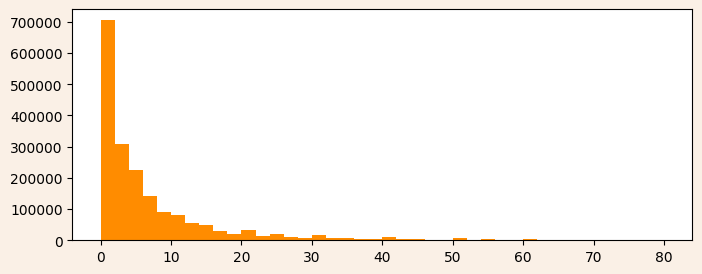

In [ ]:
fig,ax = plt.subplots(figsize=(8,3))
fig.set_facecolor("linen")
plt.hist(loans["JobsSupported"],color="darkorange",range=(np.nanpercentile(loans["JobsSupported"],1),np.nanpercentile(loans["JobsSupported"],99)),bins=40)
plt.show()

###**Save combined data into csv file**

In [ ]:
# Save combined loan dataset to CSV
loans.to_csv(path_gdrive + "/data/combined_loans_data.csv", index=False)

---

# **1. Exploratory Data Analysis(EDA) Summary**


- ### **Loan Status**

  Most loans in the dataset were paid in full (PIF), representing 59.9% of all records. The next largest groups are EXEMPT (15.3%), CANCLD (12.1%), and CHGOFF (11.3%), while COMMIT accounts for only 1.3%. Missing values are essentially zero. Overall, the distribution is highly imbalanced, with PIF dominating the dataset, something we’ll need to consider when modeling.

  We will  be considering only paid in full PIF(59.9%) andcharged off loan status data CHGOFF (11.3%)

- ### **Loan / Financial Analysis**

  Loan size and guarantee amounts show very weak relationships with default (correlations around –0.08), meaning borrowers with larger loan amounts are not significantly more likely to default. Interest rate also shows almost no relationship (–0.01), suggesting pricing differences do not strongly separate good and bad borrowers in this dataset. Loan term is more informative: longer-term loans have a stronger negative correlation with default (–0.25), indicating shorter-term loans default at higher rates. Revolver loans show higher default rates (13%) compared to non-revolver loans (11%), suggesting revolving credit structures carry additional repayment risk.

  
- ### **Industry (NAICS) NAICSCode**

  Loan performance varies noticeably across industries. Some sectors show higher default rates, including Retail Trade (NAICS 44–45), Information (NAICS 51), and Wholesale Trade (NAICS 42), each with default rates around 14–15%, making them among the riskiest industries in the dataset. Other sectors, such as Management of Companies and Enterprises (NAICS 55), Health Care and Social Assistance (NAICS 62), and Agriculture, Forestry, Fishing and Hunting (NAICS 11), show much lower default rates, generally below 7%.

  This variation highlights that industry type is an important driver of loan risk, and including NAICS sector information in the modeling process should help improve predictive performance.

- ### **Business Characteristics**
  Corporations make up the majority of borrowers, but individual-owned businesses have much higher default rates, and partnerships are the lowest risk group. Business age also shows a clear pattern: younger businesses default more frequently, while firms operating for five or more years have the lowest risk. JobsSupported is mostly concentrated in small numbers and shows a weak relationship with default. RevolverStatus shows a modest difference, with revolver loans defaulting slightly more often than non-revolver loans. Overall, these business characteristics help identify which borrowers are more likely to default.

- ### **Geographic**
  The highest rates appear in American Samoa (AS) and several southern and western states, including Nevada (15.9%), Florida (15.4%), Georgia (13.9%), and Illinois (13.7%). Other states such as Alabama, Arkansas, Tennessee, and West Virginia also show elevated default rates above 12%. These differences reflect underlying regional economic conditions and suggest that state-level geography plays a meaningful role in loan performance.


- ### **Outliners**

  | Variable               | Outlier Percentage |
  |------------------------|--------------------|
  | GrossApproval          | 11.2451%           |
  | SBAGuaranteedApproval | 11.0702%           |
  | InitialInterestRate    | 0.6986%            |
  | TerminMonths           | 14.5207%           |
  | JobsSupported          | 8.9782%            |
  | GrossChargeoffAmount   | 11.3105%           |


#2. **Missing Value Handling and  Variable transformations**
  - Missing numeric values were imputed using the median, while missing categorical values were encoded as their own category

  - New Columns Added to `cleaned_loans`

    | Column Name                   | Description |
    |------------------------------|-------------|
    | **is_default**               | Binary default indicator (1 = CHGOFF, 0 = otherwise) |
    | **Log_GrossApproval**        | Log-transformed gross loan amount |
    | **Log_SBAGuaranteedApproval**| Log-transformed SBA guaranteed amount |
    | **Log_JobsSupported**        | Log-transformed job count |
    | **Log_GrossChargeoffAmount** | Log-transformed charge-off amount |
    | **TerminMonths_Capped**      | Loan term capped between 12 and 360 months |
    | **ApprovalDate_Timestamp**          | Numeric timestamp version of ApprovalDate |
    | **FirstDisbursementDate_Timestamp** | Numeric timestamp version of FirstDisbursementDate |
    | **ApprovalYear**             | Extracted calendar year from ApprovalDate |


# **Exploratory Data Analysis (EDA)**

### **Summary statistics**

In [ ]:
# shape
loans.shape

(1902187, 43)

In [ ]:
# column names
loans.columns

Index(['AsOfDate', 'Program', 'BorrName', 'BorrStreet', 'BorrCity',
       'BorrState', 'BorrZip', 'LocationID', 'BankName', 'BankFDICNumber',
       'BankNCUANumber', 'BankStreet', 'BankCity', 'BankState', 'BankZip',
       'GrossApproval', 'SBAGuaranteedApproval', 'ApprovalDate', 'ApprovalFY',
       'FirstDisbursementDate', 'ProcessingMethod', 'Subprogram',
       'InitialInterestRate', 'FixedorVariableInterestRate', 'TerminMonths',
       'NAICSCode', 'NAICSDescription', 'FranchiseCode', 'FranchiseName',
       'ProjectCounty', 'ProjectState', 'SBADistrictOffice',
       'CongressionalDistrict', 'BusinessType', 'BusinessAge', 'LoanStatus',
       'PaidinFullDate', 'ChargeoffDate', 'GrossChargeoffAmount',
       'RevolverStatus', 'JobsSupported', 'CollateralInd',
       'SoldSecondMarketInd'],
      dtype='object')

In [ ]:
# data types
loans.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1902187 entries, 0 to 347513
Data columns (total 43 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   AsOfDate                     object 
 1   Program                      object 
 2   BorrName                     object 
 3   BorrStreet                   object 
 4   BorrCity                     object 
 5   BorrState                    object 
 6   BorrZip                      int64  
 7   LocationID                   object 
 8   BankName                     object 
 9   BankFDICNumber               float64
 10  BankNCUANumber               object 
 11  BankStreet                   object 
 12  BankCity                     object 
 13  BankState                    object 
 14  BankZip                      object 
 15  GrossApproval                float64
 16  SBAGuaranteedApproval        float64
 17  ApprovalDate                 object 
 18  ApprovalFY                   int64  
 19  FirstD

In [ ]:
# quick peek
loans.head()

,AsOfDate,Program,BorrName,BorrStreet,BorrCity,BorrState,BorrZip,LocationID,BankName,BankFDICNumber,...,BusinessType,BusinessAge,LoanStatus,PaidinFullDate,ChargeoffDate,GrossChargeoffAmount,RevolverStatus,JobsSupported,CollateralInd,SoldSecondMarketInd
0,9/30/2025,7A,O'NEILL'S UPHOLSTERY,1500 ST. LOUIS,SPRINGFIELD,MO,65806,53803.0,"U.S. Bank, National Association",6548.0,...,INDIVIDUAL,NaN,PIF,7/31/2005,NaN,0.0,0,0.0,NaN,NaN
1,9/30/2025,7A,K AND K INCORPORATED,11636 SE 5TH,BELLEVUE,WA,98005,9551.0,"Bank of America, National Association",3510.0,...,CORPORATION,NaN,CANCLD,NaN,NaN,0.0,0,0.0,NaN,NaN
2,9/30/2025,7A,INTELLISYS INC.,4641 CROSS ROADS PARK DRIVE,LIVERPOOL,NY,13088,46391.0,Manufacturers and Traders Trust Company,588.0,...,CORPORATION,NaN,PIF,7/31/2005,NaN,0.0,0,0.0,NaN,NaN
3,9/30/2025,7A,ROOFING CONTRACTORS INC.,"2221 DEVONSHIRE ROAD, N.W.",CANTON,OH,44708,57328.0,The Huntington National Bank,6560.0,...,CORPORATION,NaN,CANCLD,NaN,NaN,0.0,0,0.0,NaN,NaN
4,9/30/2025,7A,CHUCK ROAST EQUIPMENT INC.,ODELL HILL ROAD,CONWAY,NH,3818,29633.0,Camden National Bank,4255.0,...,CORPORATION,NaN,PIF,6/30/2006,NaN,0.0,0,0.0,NaN,Y


In [ ]:
# missing values per column
loans.isna().sum().sort_values(ascending=False)

,0
BankNCUANumber,1862015
FranchiseName,1753895
FranchiseCode,1753641
ChargeoffDate,1686945
BusinessAge,1443502
SoldSecondMarketInd,1435502
InitialInterestRate,972295
FixedorVariableInterestRate,972294
PaidinFullDate,763188
CollateralInd,363450


In [ ]:
# numeric columns summary
loans.describe().T

,count,mean,std,min,25%,50%,75%,max
BorrZip,1902187.0,51919.777398,31261.736064,0.0,23236.00,52748.0,80304.0,99999.00
BankFDICNumber,1714570.0,16321.187040,17036.726695,14.0,3511.00,8273.0,24045.0,91359.00
GrossApproval,1902182.0,302454.907758,569683.267963,-120000.0,37000.00,100000.0,300000.0,5000000.00
SBAGuaranteedApproval,1902182.0,224257.026254,436630.986539,-96000.0,22500.00,75000.0,225000.0,4500000.00
ApprovalFY,1902187.0,2009.474660,9.226255,1992.0,2003.00,2008.0,2017.0,2025.00
InitialInterestRate,929892.0,7.352830,2.353531,0.0,5.75,6.5,9.0,56.00
TerminMonths,1902187.0,115.833329,76.780867,0.0,68.00,84.0,120.0,847.00
NAICSCode,1708548.0,523574.258254,174924.908582,111110.0,424820.00,531312.0,624410.0,928120.00
CongressionalDistrict,1898827.0,9.456029,10.756552,0.0,2.00,5.0,12.0,53.00
GrossChargeoffAmount,1902187.0,12178.227011,75487.567622,0.0,0.00,0.0,0.0,4706180.93


In [ ]:
loans['LoanStatus'].value_counts(normalize=True)

,proportion
LoanStatus,
PIF,0.598784
EXEMPT,0.153638
CANCLD,0.121151
CHGOFF,0.113179
COMMIT,0.013247


### **Univariate analysis**

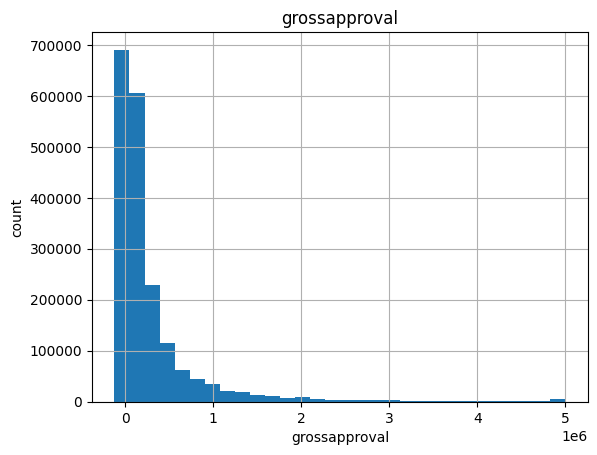

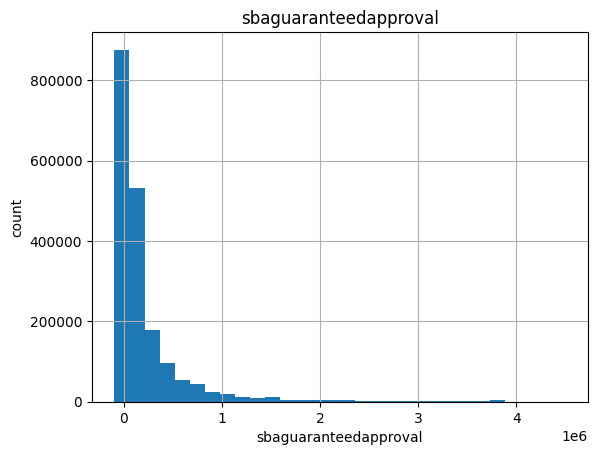

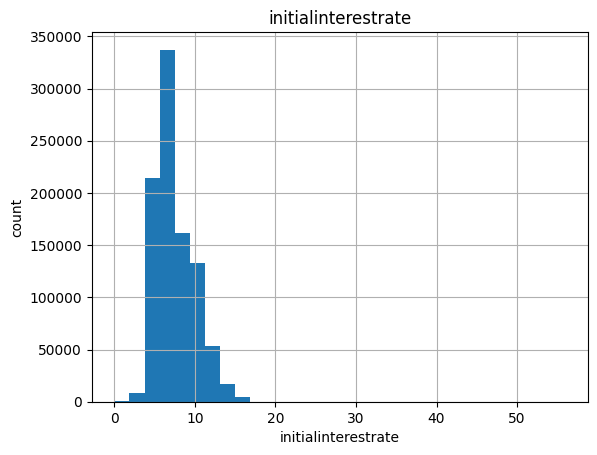

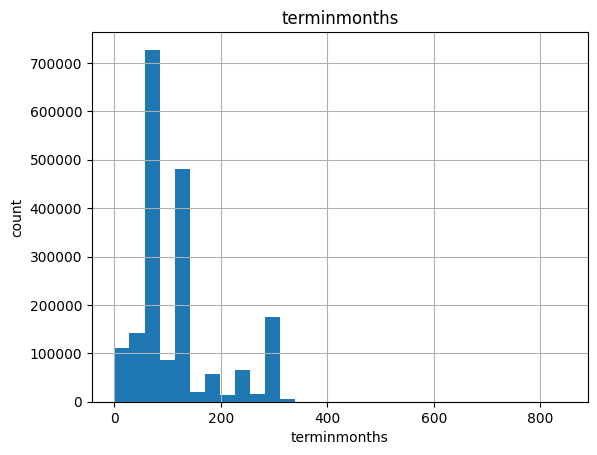

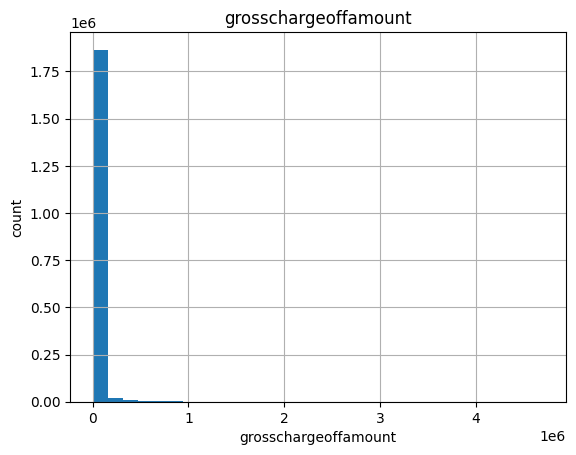

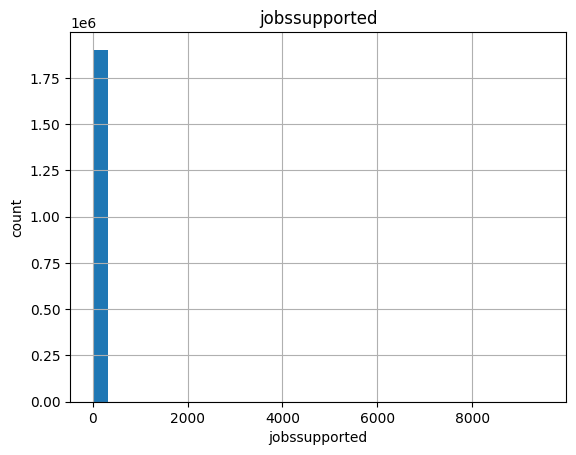

In [ ]:
# numeric distributions
# 'NAICSCode', 'FranchiseCode'
num_cols = ['GrossApproval', 'SBAGuaranteedApproval', 'InitialInterestRate',
            'TerminMonths', 'GrossChargeoffAmount', 'JobsSupported']

for col in num_cols:
    plt.figure()
    loans[col].hist(bins=30)
    plt.title(col.lower())
    plt.xlabel(col.lower())
    plt.ylabel('count')
    plt.show()

In [ ]:
# categorical value counts
cat_cols = ['Program', 'BorrState', 'BankState', 'ProcessingMethod',
            'Subprogram', 'BusinessType', 'BusinessAge', 'LoanStatus',
            'CollateralInd', 'SoldSecondMarketInd']

for col in cat_cols:
    print(col.lower())
    print(loans[col].value_counts(dropna=False))
    print('-' * 40)

program
Program
7A    1902187
Name: count, dtype: int64
----------------------------------------
borrstate
BorrState
CA    246130
TX    150527
NY    125536
FL     99543
OH     85988
       ...  
TQ         7
FM         6
           5
MH         4
AE         2
Name: count, Length: 62, dtype: int64
----------------------------------------
bankstate
BankState
OH    322830
NC    161280
CA    145115
SD    144888
DE    116076
       ...  
Lu         4
Gu         3
Te         3
Is         2
32         1
Name: count, Length: 67, dtype: int64
----------------------------------------
processingmethod
ProcessingMethod
SBA Express Program                                             783327
Preferred Lenders Program                                       584199
7a General                                                      210423
Low Documentation Program                                       144730
Certified Lenders Program                                        53199
Community Express             

#### **Bivariate analysis**

In [ ]:
# numeric variables vs loan status
for col in num_cols:
    print(f'\n{col.lower()} by loanstatus')
    print(loans.groupby('LoanStatus')[col].mean())


grossapproval by loanstatus
LoanStatus
CANCLD    304532.817486
CHGOFF    172211.284426
COMMIT    398685.868487
EXEMPT    557714.622231
PIF       259028.682439
Name: GrossApproval, dtype: float64

sbaguaranteedapproval by loanstatus
LoanStatus
CANCLD    226133.558196
CHGOFF    124862.919381
COMMIT    285396.464860
EXEMPT    419924.732847
PIF       191107.055011
Name: SBAGuaranteedApproval, dtype: float64

initialinterestrate by loanstatus
LoanStatus
CANCLD     7.282094
CHGOFF     7.216190
COMMIT    10.237123
EXEMPT     8.498977
PIF        6.518494
Name: InitialInterestRate, dtype: float64

terminmonths by loanstatus
LoanStatus
CANCLD    120.137426
CHGOFF     62.217267
COMMIT    130.248819
EXEMPT    151.024483
PIF       115.748552
Name: TerminMonths, dtype: float64

grosschargeoffamount by loanstatus
LoanStatus
CANCLD         0.000000
CHGOFF    107601.283408
COMMIT         0.000000
EXEMPT         0.000000
PIF            0.000000
Name: GrossChargeoffAmount, dtype: float64

jobssupported 

In [ ]:
# categorical variables vs loan status
for col in cat_cols:
    print(f'\n{col.lower()} distribution by loanstatus')
    print(loans.groupby('LoanStatus')[col].value_counts(normalize=True))


program distribution by loanstatus
LoanStatus  Program
CANCLD      7A         1.0
CHGOFF      7A         1.0
COMMIT      7A         1.0
EXEMPT      7A         1.0
PIF         7A         1.0
Name: proportion, dtype: float64

borrstate distribution by loanstatus
LoanStatus  BorrState
CANCLD      CA           0.125180
            NY           0.079071
            TX           0.074844
            FL           0.053681
            OH           0.046804
                           ...   
PIF                      0.000004
            TQ           0.000004
            FM           0.000004
            MH           0.000003
            AE           0.000002
Name: proportion, Length: 288, dtype: float64

bankstate distribution by loanstatus
LoanStatus  BankState
CANCLD      OH           1.658399e-01
            NC           8.932167e-02
            NY           6.715793e-02
            SD           6.428054e-02
            DE           6.083295e-02
                             ...     
PIF     

### **correlation matrix**

- Date-related variables such as PaidInFullDate and FirstDisbursementDate show the strongest relationships because they directly reflect loan performance timing but can't be used prediction model.
- Financial risk variables like InitialInterestRate and GrossChargeoffAmount are also meaningfully correlated, suggesting risk-based pricing and actual loss amounts are connected to loan outcomes.
- Business characteristics such as BusinessAge and NAICSCode show weaker but still meaningful correlations, indicating that industry and business maturity influence loan performance.


Correlations with LoanStatus:

LoanStatus                     1.000000
PaidinFullDate                 0.835317
FirstDisbursementDate          0.740932
ChargeoffDate                  0.485499
GrossChargeoffAmount           0.219317
InitialInterestRate            0.145750
SoldSecondMarketInd            0.125392
TerminMonths                   0.091653
CollateralInd                  0.082612
BankZip                        0.076284
ApprovalDate                   0.060051
ApprovalFY                     0.059730
AsOfDate                       0.050262
BusinessAge                    0.049208
Subprogram                     0.034094
LocationID                     0.030445
RevolverStatus                 0.027650
BankStreet                     0.026888
ProcessingMethod               0.026368
BankName                       0.022927
BorrZip                        0.022177
BusinessType                   0.020226
BankFDICNumber                 0.019960
CongressionalDistrict          0.018618
BorrStat

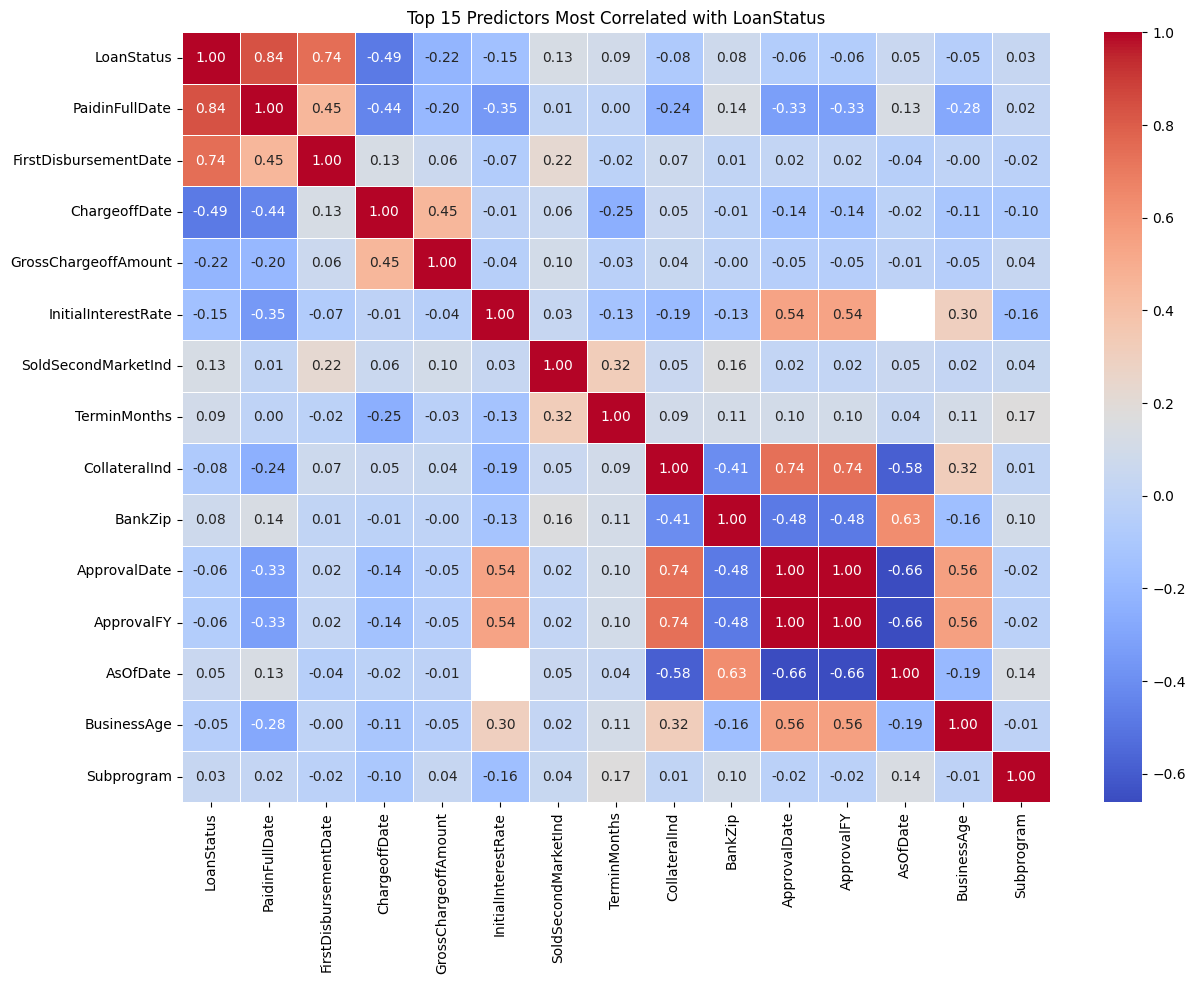

In [ ]:
# correlation for all columns

# copy full df
temp = loans.copy()

# identify date columns
date_cols = ['AsOfDate', 'ApprovalDate', 'FirstDisbursementDate',
             'PaidinFullDate', 'ChargeoffDate']

# convert date columns → numeric timestamps
for col in date_cols:
    if col in temp.columns:
        temp[col] = pd.to_datetime(temp[col], errors='coerce').astype('int64') // 10**9

# convert all object columns → category codes
cat_cols = temp.select_dtypes(include=['object']).columns
for col in cat_cols:
    temp[col] = temp[col].astype('category').cat.codes

# ensure all columns are numeric
for col in temp.columns:
    temp[col] = pd.to_numeric(temp[col], errors='coerce')

# compute full correlation matrix
corr_all = temp.corr()

# correlation of all predictors with loanstatus
loan_corr = corr_all['LoanStatus'].abs().sort_values(ascending=False)

print("\nCorrelations with LoanStatus:\n")
print(loan_corr)

# select top 15 columns for heatmap
top15_cols = loan_corr.head(15).index.tolist()

# create heatmap for top 15 columns
plt.figure(figsize=(14,10))
sns.heatmap(
    corr_all.loc[top15_cols, top15_cols],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Top 15 Predictors Most Correlated with LoanStatus")
plt.show()

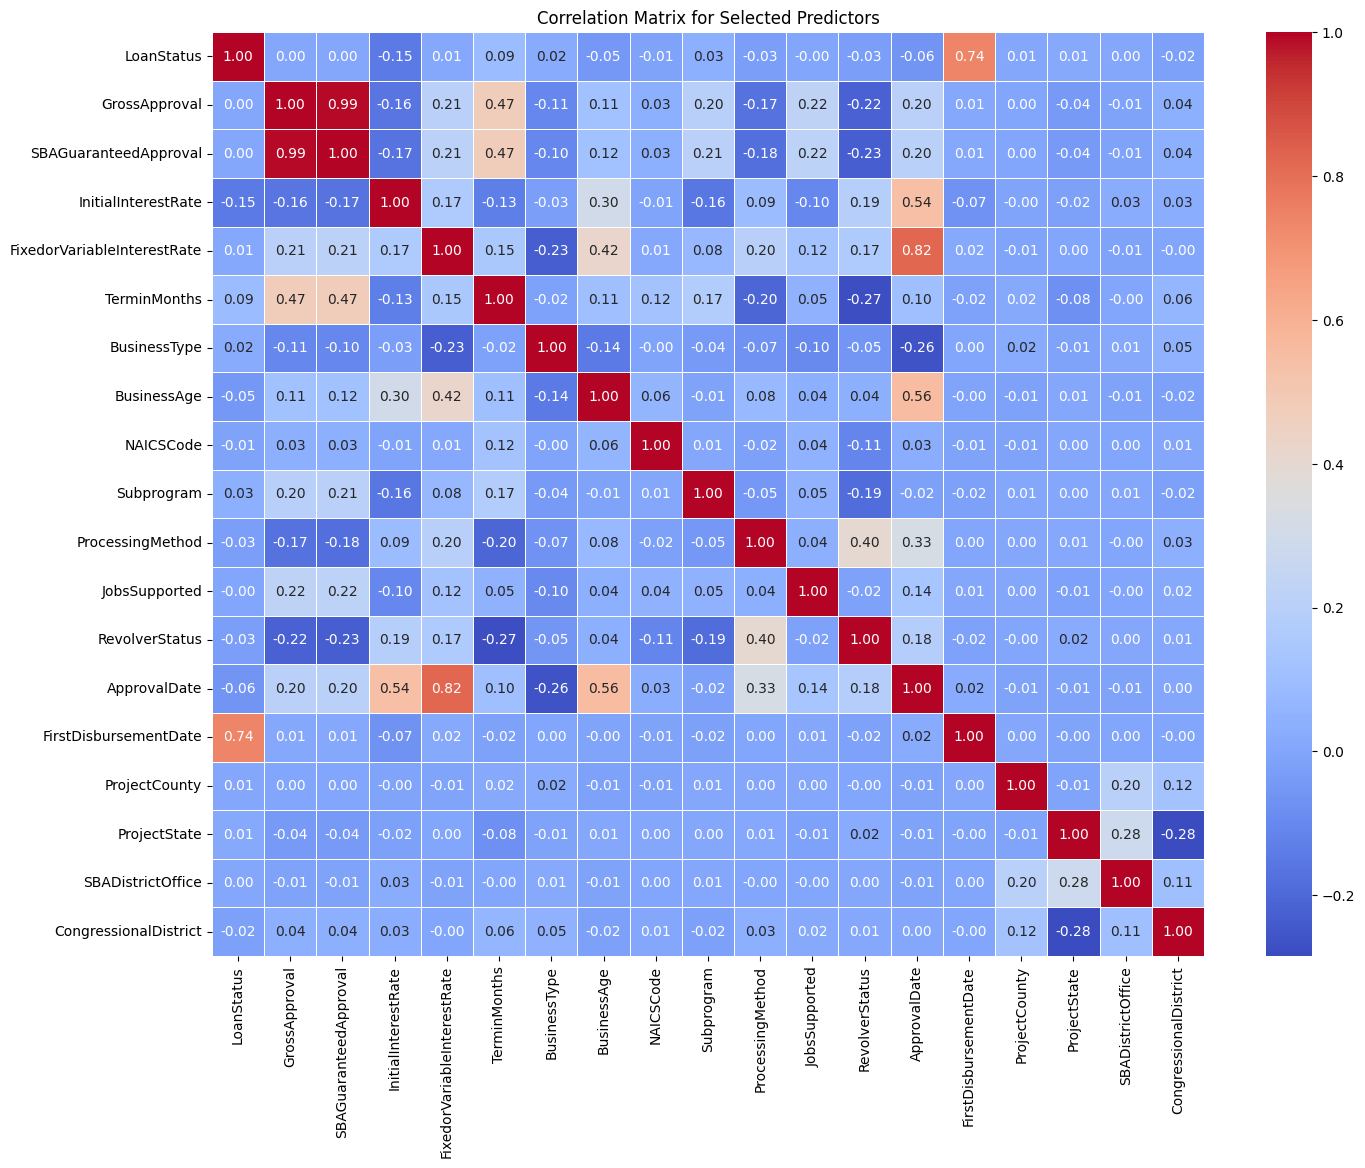

In [ ]:
# correlation matrix for selected predictors

# list of valid predictors
selected_cols = [
    'LoanStatus',
    'GrossApproval',
    'SBAGuaranteedApproval',
    'InitialInterestRate',
    'FixedorVariableInterestRate',
    'TerminMonths',
    'BusinessType',
    'BusinessAge',
    'NAICSCode',
    'Subprogram',
    'ProcessingMethod',
    'JobsSupported',
    'RevolverStatus',
    'ApprovalDate',
    'FirstDisbursementDate',
    'ProjectCounty',
    'ProjectState',
    'SBADistrictOffice',
    'CongressionalDistrict'
]

# create temp df
temp = loans[selected_cols].copy()

# convert date columns → timestamps
date_cols = ['ApprovalDate', 'FirstDisbursementDate']
for col in date_cols:
    temp[col] = pd.to_datetime(temp[col], errors='coerce').astype('int64') // 10**9

# convert categorical/text columns → numeric codes
cat_cols = temp.select_dtypes(include=['object']).columns
for col in cat_cols:
    temp[col] = temp[col].astype('category').cat.codes

# convert remaining columns to numeric
for col in temp.columns:
    temp[col] = pd.to_numeric(temp[col], errors='coerce')

# compute correlation matrix
corr_mat = temp.corr()

# plot heatmap with correlation values
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_mat,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Matrix for Selected Predictors")
plt.show()


### **Loan Status Analysis**

unique loanstatus values:
['PIF' 'CANCLD' 'CHGOFF' 'EXEMPT' 'COMMIT' nan]

loanstatus counts:
LoanStatus
PIF       1138998
EXEMPT     292247
CANCLD     230452
CHGOFF     215288
COMMIT      25199
NaN             3
Name: count, dtype: int64

loanstatus proportions:
LoanStatus
PIF       0.598783
EXEMPT    0.153637
CANCLD    0.121151
CHGOFF    0.113179
COMMIT    0.013247
NaN       0.000002
Name: proportion, dtype: float64


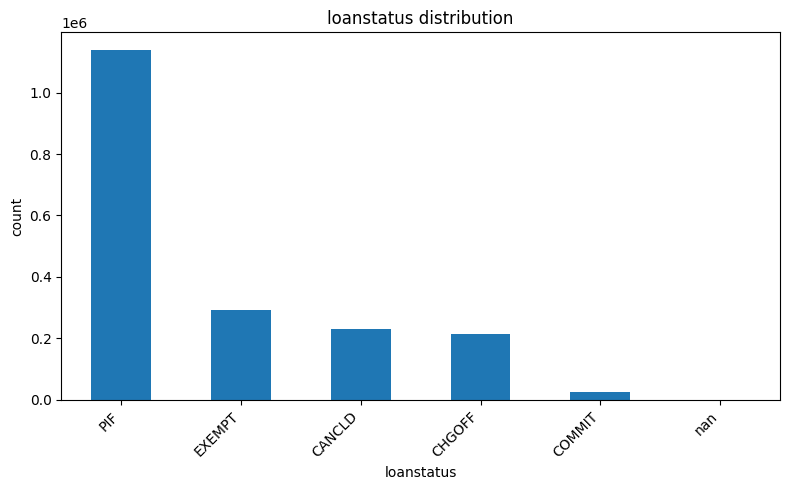


missing loanstatus %: 0.0000


In [ ]:
# eda on target variable loanstatus

# unique values
print("unique loanstatus values:")
print(loans['LoanStatus'].unique())

# counts and proportions
loanstatus_counts = loans['LoanStatus'].value_counts(dropna=False)
loanstatus_props = loans['LoanStatus'].value_counts(normalize=True, dropna=False)

print("\nloanstatus counts:")
print(loanstatus_counts)

print("\nloanstatus proportions:")
print(loanstatus_props)

# bar plot of loanstatus distribution
plt.figure(figsize=(8,5))
loanstatus_counts.plot(kind='bar')
plt.title('loanstatus distribution')
plt.xlabel('loanstatus')
plt.ylabel('count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# missing values
missing_share = loans['LoanStatus'].isna().mean()
print(f"\nmissing loanstatus %: {missing_share:.4f}")

### **Industry (NAICS) Analysis**

### NAICS2 → Industry Sector Lookup Table

| NAICS2 | Industry Name |
|--------|----------------|
| 11 | Agriculture, Forestry, Fishing and Hunting |
| 21 | Mining, Quarrying, and Oil and Gas Extraction |
| 22 | Utilities |
| 23 | Construction |
| 31 | Manufacturing |
| 32 | Manufacturing |
| 33 | Manufacturing |
| 42 | Wholesale Trade |
| 44 | Retail Trade |
| 45 | Retail Trade |
| 48 | Transportation and Warehousing |
| 49 | Transportation and Warehousing |
| 51 | Information |
| 52 | Finance and Insurance |
| 53 | Real Estate and Rental and Leasing |
| 54 | Professional, Scientific, and Technical Services |
| 55 | Management of Companies and Enterprises |
| 56 | Administrative and Support and Waste Management |
| 61 | Educational Services |
| 62 | Health Care and Social Assistance |
| 71 | Arts, Entertainment, and Recreation |
| 72 | Accommodation and Food Services |
| 81 | Other Services (except Public Administration) |
| 92 | Public Administration |


default rates by naics sector:
NAICS2
45    0.148610
51    0.145631
44    0.140635
42    0.131937
53    0.129311
32    0.118404
72    0.116615
48    0.116237
56    0.115488
23    0.114492
81    0.114448
na    0.112281
52    0.112276
92    0.111111
71    0.109104
49    0.106969
31    0.105778
61    0.103897
33    0.099834
54    0.099665
Name: is_default, dtype: float64


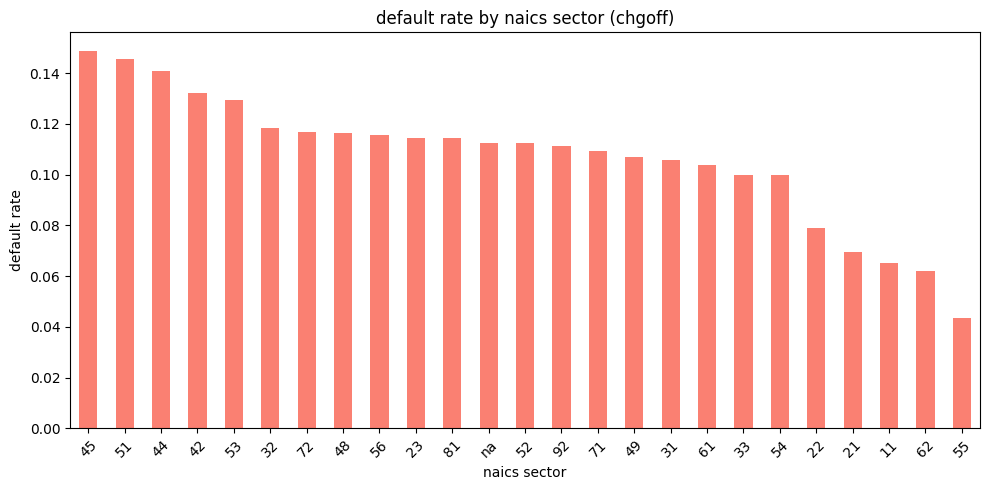

In [ ]:
# create NAICS2 (2-digit sector code)
loans['NAICS2'] = loans['NAICSCode'].astype(str).str[:2]

# clean default indicator
loans['is_default'] = (loans['LoanStatus'] == 'CHGOFF').astype(int)

# default rate by naics sector
sector_default_rates = (
    loans.groupby('NAICS2')['is_default']
    .mean()
    .sort_values(ascending=False)
)

print("\ndefault rates by naics sector:")
print(sector_default_rates.head(20))

# plot default rates
plt.figure(figsize=(10,5))
sector_default_rates.plot(kind='bar', color='salmon')
plt.title('default rate by naics sector (chgoff)')
plt.xlabel('naics sector')
plt.ylabel('default rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Business chracteristics**

business type counts:
BusinessType
CORPORATION    1494459
INDIVIDUAL      350560
PARTNERSHIP      53187
                  3981
Name: count, dtype: int64


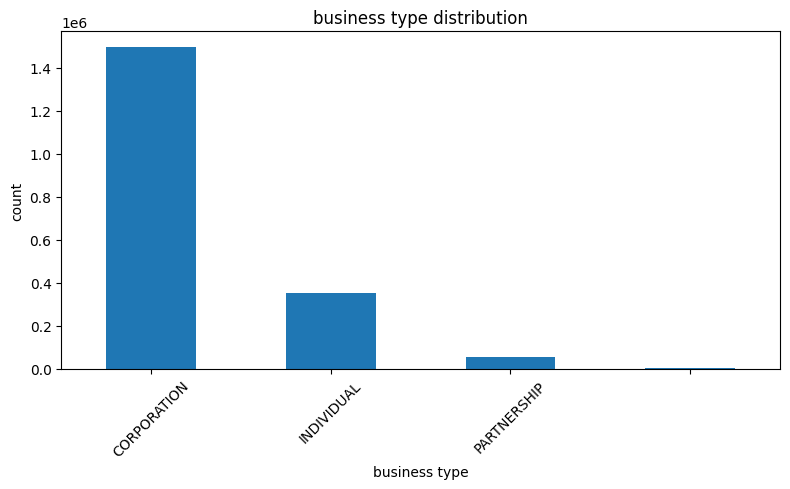


default rate by business type:
BusinessType
               0.315247
INDIVIDUAL     0.153112
CORPORATION    0.104016
PARTNERSHIP    0.092335
Name: is_default, dtype: float64


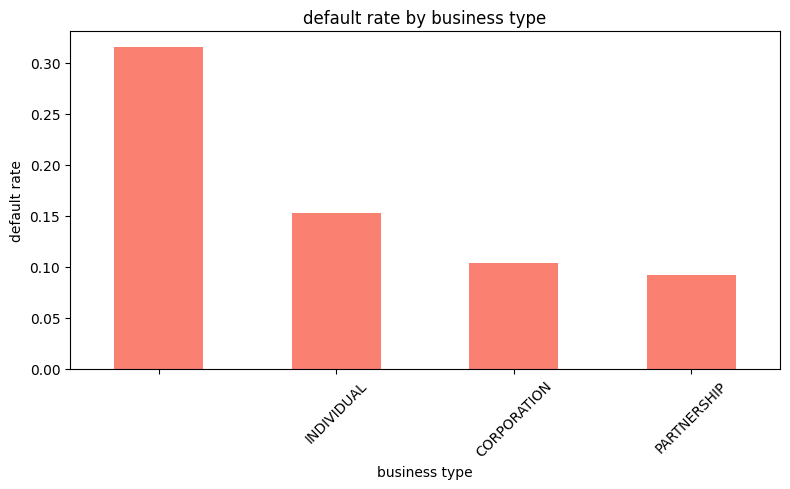


business age distribution:
BusinessAge
NaN                                       1443502
Existing or more than 2 years old          244770
Startup, Loan Funds will Open Business      74839
New Business or 2 years or less             58084
Change of Ownership                         46160
Unanswered                                  22359
Existing, 5 or more years                    7186
New, Less than 1 Year old                    2383
Less than 3 years old but at least 2         1169
Less than 4 years old but at least 3          927
Less than 5 years old but at least 4          808
Name: count, dtype: int64


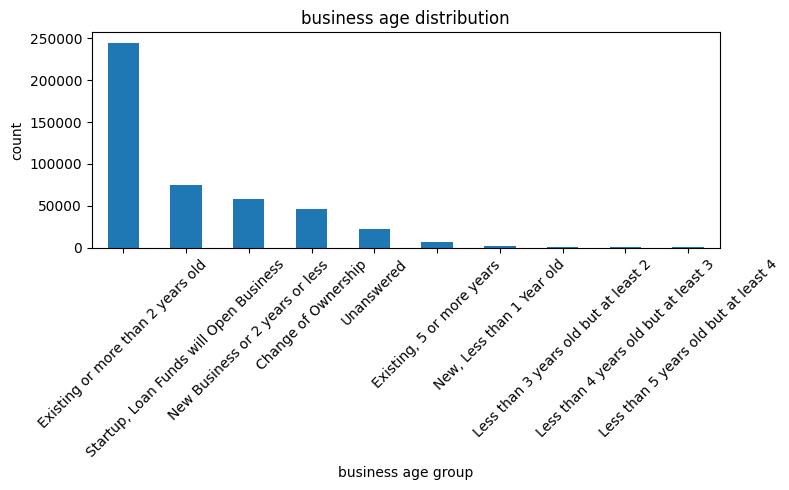


default rate by business age:
BusinessAge
Less than 4 years old but at least 3      0.089536
Less than 5 years old but at least 4      0.084158
Less than 3 years old but at least 2      0.083832
New, Less than 1 Year old                 0.075955
Existing, 5 or more years                 0.053159
Unanswered                                0.050405
Startup, Loan Funds will Open Business    0.025922
Existing or more than 2 years old         0.020305
New Business or 2 years or less           0.017320
Change of Ownership                       0.013432
Name: is_default, dtype: float64


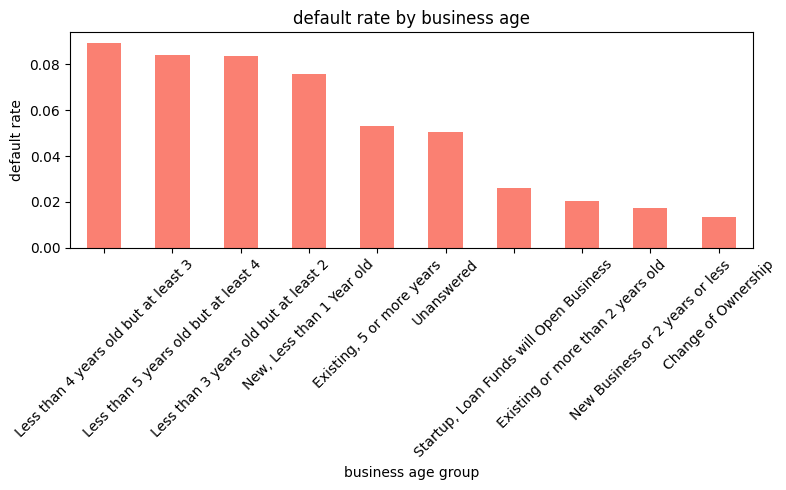

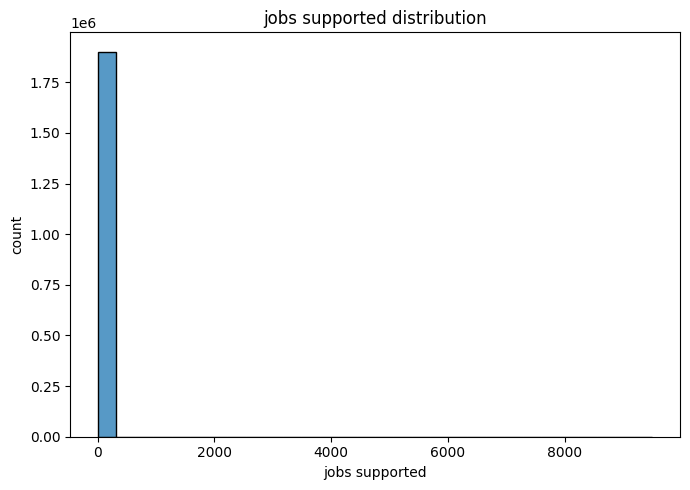


corr between jobs supported and default: -0.019

revolver status counts:
RevolverStatus
0    1434945
1     467242
Name: count, dtype: int64

default rate by revolver status:
RevolverStatus
0    0.107706
1    0.129988
Name: is_default, dtype: float64


In [ ]:
# eda on business characteristics

# ------------------------------
# business type distribution
# ------------------------------
print("business type counts:")
print(loans['BusinessType'].value_counts(dropna=False))

plt.figure(figsize=(8,5))
loans['BusinessType'].value_counts().plot(kind='bar')
plt.title('business type distribution')
plt.xlabel('business type')
plt.ylabel('count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# default rate by business type
bt_default = loans.groupby('BusinessType')['is_default'].mean().sort_values(ascending=False)

print("\ndefault rate by business type:")
print(bt_default)

plt.figure(figsize=(8,5))
bt_default.plot(kind='bar', color='salmon')
plt.title('default rate by business type')
plt.xlabel('business type')
plt.ylabel('default rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------
# business age distribution
# ------------------------------
print("\nbusiness age distribution:")
print(loans['BusinessAge'].value_counts(dropna=False))

plt.figure(figsize=(8,5))
loans['BusinessAge'].value_counts().plot(kind='bar')
plt.title('business age distribution')
plt.xlabel('business age group')
plt.ylabel('count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# default rate by business age
ba_default = loans.groupby('BusinessAge')['is_default'].mean().sort_values(ascending=False)

print("\ndefault rate by business age:")
print(ba_default)

plt.figure(figsize=(8,5))
ba_default.plot(kind='bar', color='salmon')
plt.title('default rate by business age')
plt.xlabel('business age group')
plt.ylabel('default rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------
# jobs supported (numeric)
# ------------------------------
plt.figure(figsize=(7,5))
sns.histplot(loans['JobsSupported'], bins=30, kde=False)
plt.title('jobs supported distribution')
plt.xlabel('jobs supported')
plt.ylabel('count')
plt.tight_layout()
plt.show()

# relationship with default
jobs_default = loans[['JobsSupported', 'is_default']].corr().iloc[0,1]
print(f"\ncorr between jobs supported and default: {jobs_default:.3f}")


# ------------------------------
# revolver status
# ------------------------------
print("\nrevolver status counts:")
print(loans['RevolverStatus'].value_counts(dropna=False))

rs_default = loans.groupby('RevolverStatus')['is_default'].mean()
print("\ndefault rate by revolver status:")
print(rs_default)

### **Geographic Analysis**

project state counts:
ProjectState
CA          246195
TX          150387
NY          125635
FL           99429
OH           86040
PA           72203
IL           63016
NJ           59411
MI           58870
MA           56919
GA           50476
MN           49793
WA           49012
CO           44898
WI           43047
AZ           38168
MO           36890
UT           35433
NC           33921
IN           33846
MD           28962
VA           28943
CT           26033
OR           25197
PR           21105
NH           20164
TN           19684
OK           18754
KS           18322
IA           18064
LA           18006
ID           17906
KY           15994
NV           15637
MS           15392
RI           15213
SC           14852
AL           14359
MT           12584
NE           12424
AR           12275
ME           11576
NM           10688
VT            8703
HI            7820
ND            7532
WV            6571
SD            6441
DE            5250
WY            4562
AK            4

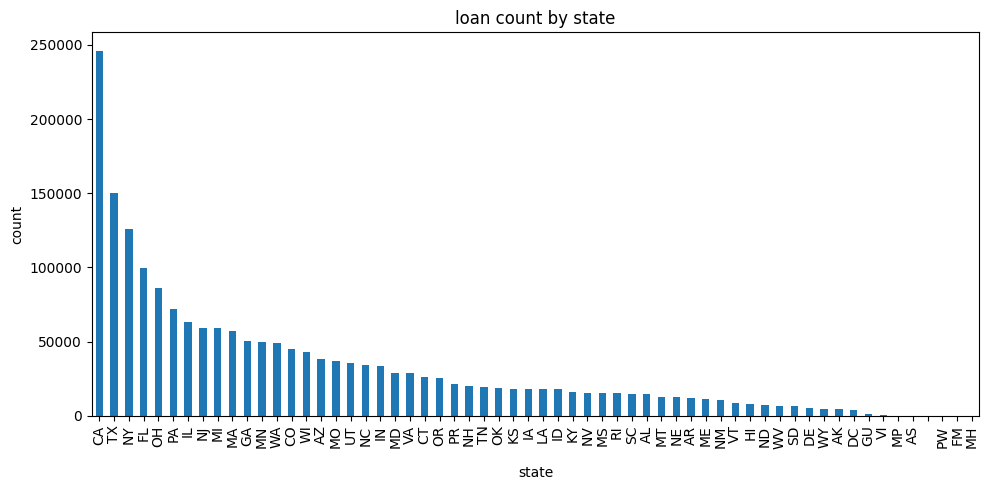


default rate by state:
ProjectState
AS    0.333333
NV    0.158534
FL    0.153949
GA    0.138541
IL    0.137457
AL    0.136569
AR    0.132138
DC    0.130836
TN    0.130156
WV    0.129661
LA    0.128679
AZ    0.127515
TX    0.126294
CA    0.125279
NY    0.123302
KY    0.122671
VA    0.120064
MD    0.118845
OK    0.117842
MO    0.117349
Name: is_default, dtype: float64


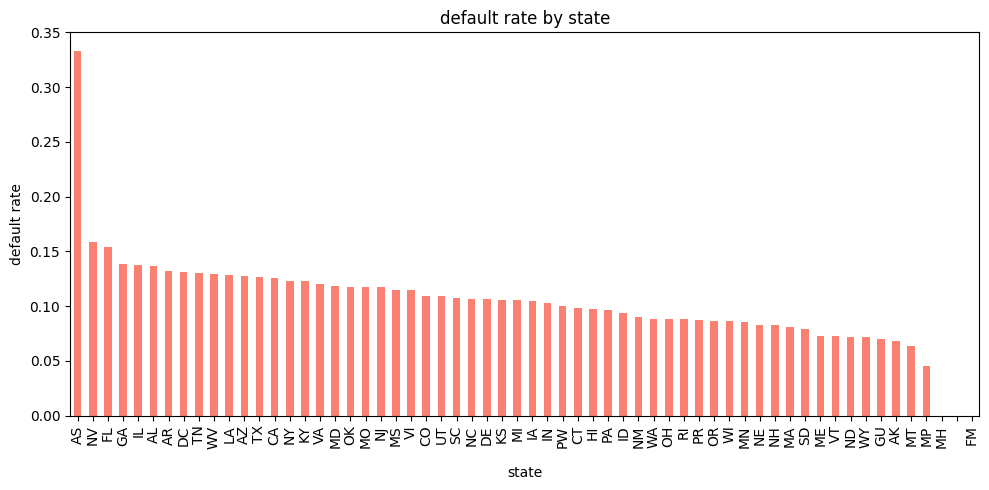


sba district office counts:
SBADistrictOffice
LOS ANGELES DISTRICT OFFICE                       84978
SOUTH FLORIDA DISTRICT OFFICE                     70503
DALLAS / FT WORTH DISTRICT OFFICE                 59988
NEW YORK DISTRICT OFFICE                          59854
NEW JERSEY DISTRICT OFFICE                        59315
                                                  ...  
SANTA ANA LOAN SERVICING & LIQUIDATION OFFICE         1
FRESNO COMMERCIAL LOAN SERVICING CENTER               1
DALLAS REGIONAL OFFICE                                1
PHILADELPHIA REGIONAL OFFICE                          1
LITTLE ROCK COMMERCIAL LOAN SERVICING CENTER          1
Name: count, Length: 88, dtype: int64


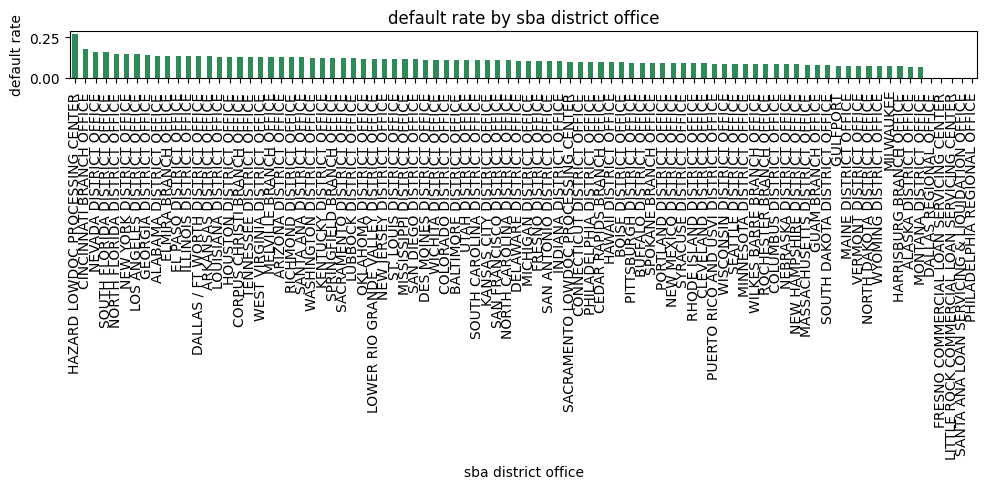

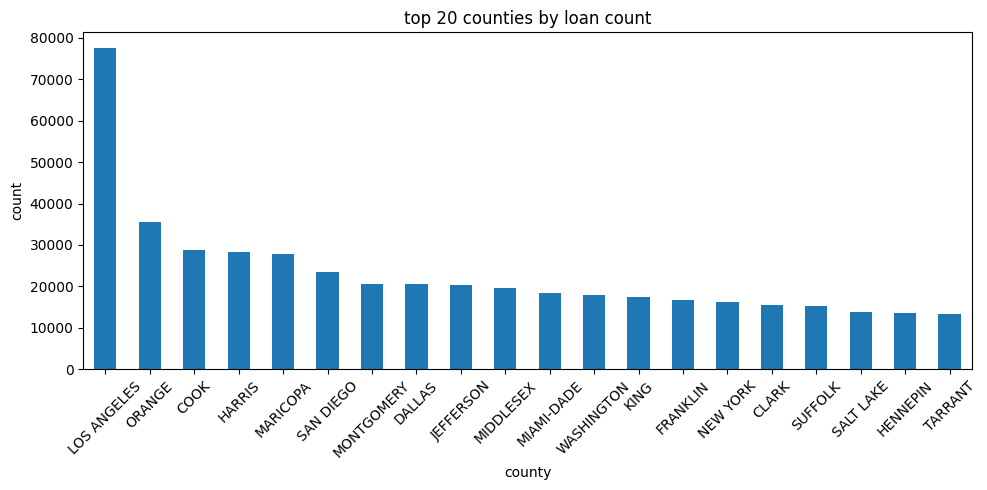

In [ ]:
# eda on geographic characteristics

# ------------------------------
# state distribution
# ------------------------------
print("project state counts:")
print(loans['ProjectState'].value_counts(dropna=False))

plt.figure(figsize=(10,5))
loans['ProjectState'].value_counts().plot(kind='bar')
plt.title('loan count by state')
plt.xlabel('state')
plt.ylabel('count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# default rate by state
state_default = loans.groupby('ProjectState')['is_default'].mean().sort_values(ascending=False)

print("\ndefault rate by state:")
print(state_default.head(20))

plt.figure(figsize=(10,5))
state_default.plot(kind='bar', color='salmon')
plt.title('default rate by state')
plt.xlabel('state')
plt.ylabel('default rate')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# ------------------------------
# sba district office analysis
# ------------------------------
print("\nsba district office counts:")
print(loans['SBADistrictOffice'].value_counts(dropna=False))

district_default = loans.groupby('SBADistrictOffice')['is_default'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
district_default.plot(kind='bar', color='seagreen')
plt.title('default rate by sba district office')
plt.xlabel('sba district office')
plt.ylabel('default rate')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# ------------------------------
# optional: county distribution (often many categories)
# ------------------------------
# count only top 20 counties for readability
county_counts = loans['ProjectCounty'].value_counts().head(20)

plt.figure(figsize=(10,5))
county_counts.plot(kind='bar')
plt.title('top 20 counties by loan count')
plt.xlabel('county')
plt.ylabel('count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Loan / Financial Variable Analysis**

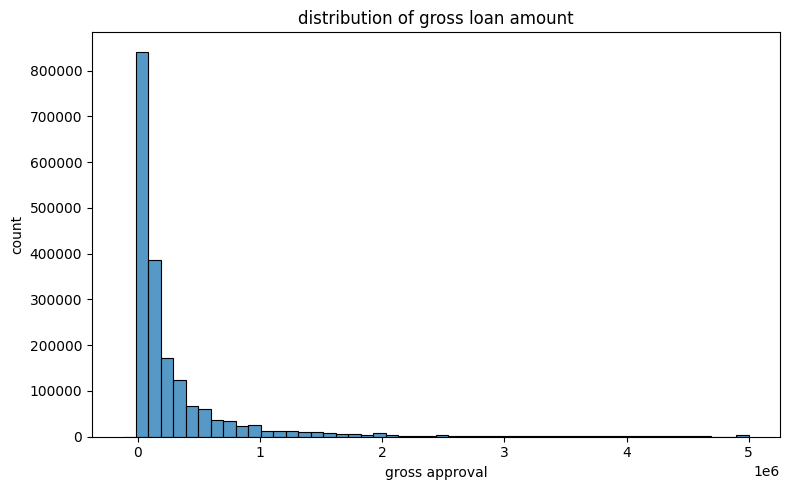

correlation between gross approval and default: -0.0817


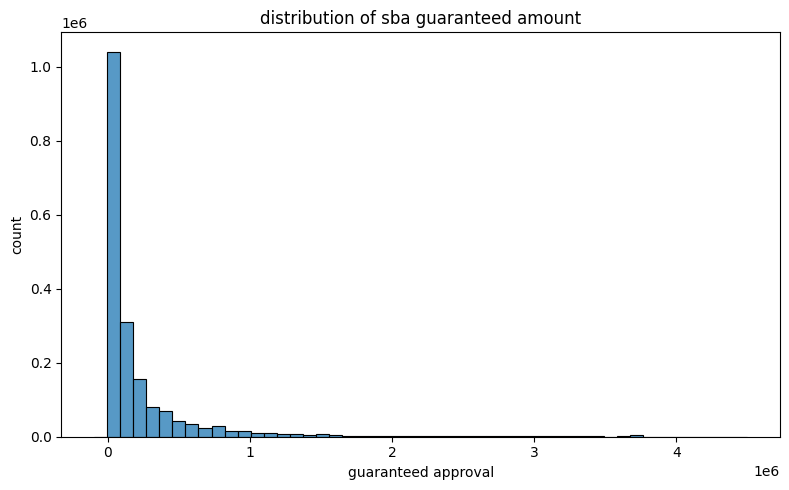

correlation between sba guarantee and default: -0.0813


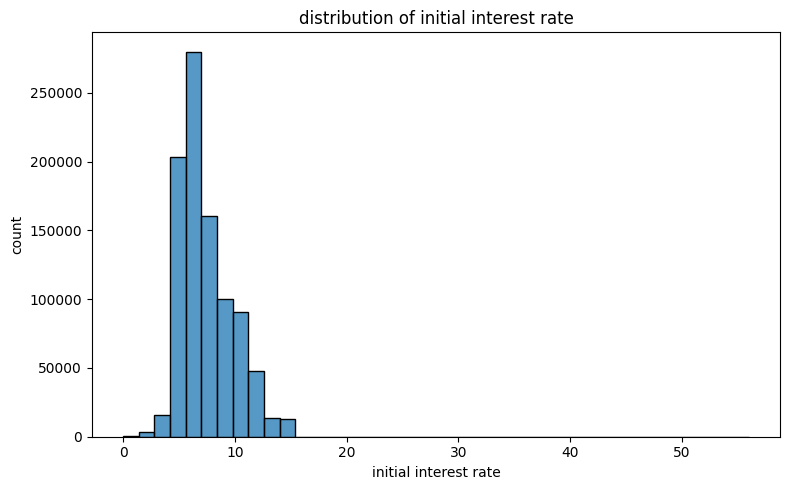

correlation between interest rate and default: -0.0126


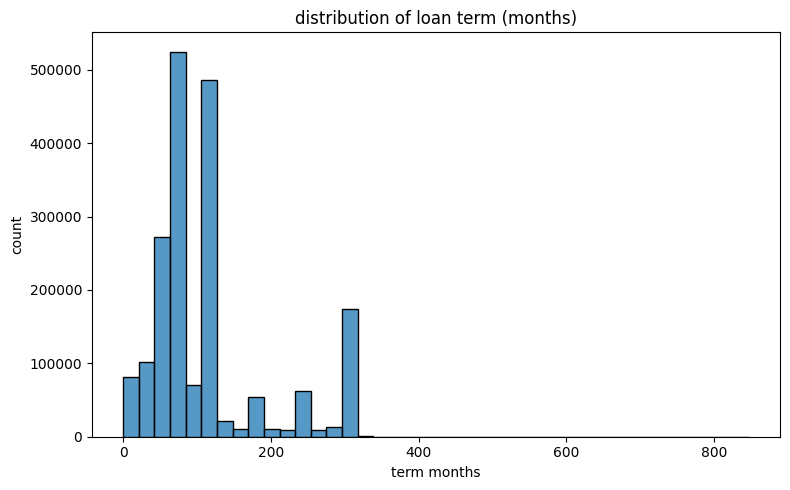

correlation between term length and default: -0.2495

revolver status counts:
RevolverStatus
0    1434945
1     467242
Name: count, dtype: int64

default rate by revolver status:
RevolverStatus
0    0.107706
1    0.129988
Name: is_default, dtype: float64


In [ ]:
# loan structure / financial variable analysis

# ------------------------------
# gross approval amount
# ------------------------------
plt.figure(figsize=(8,5))
sns.histplot(loans['GrossApproval'], bins=50, kde=False)
plt.title('distribution of gross loan amount')
plt.xlabel('gross approval')
plt.ylabel('count')
plt.tight_layout()
plt.show()

gross_corr = loans[['GrossApproval','is_default']].corr().iloc[0,1]
print(f"correlation between gross approval and default: {gross_corr:.4f}")


# ------------------------------
# sba guaranteed amount
# ------------------------------
plt.figure(figsize=(8,5))
sns.histplot(loans['SBAGuaranteedApproval'], bins=50, kde=False)
plt.title('distribution of sba guaranteed amount')
plt.xlabel('guaranteed approval')
plt.ylabel('count')
plt.tight_layout()
plt.show()

guar_corr = loans[['SBAGuaranteedApproval','is_default']].corr().iloc[0,1]
print(f"correlation between sba guarantee and default: {guar_corr:.4f}")


# ------------------------------
# interest rate
# ------------------------------
plt.figure(figsize=(8,5))
sns.histplot(loans['InitialInterestRate'], bins=40, kde=False)
plt.title('distribution of initial interest rate')
plt.xlabel('initial interest rate')
plt.ylabel('count')
plt.tight_layout()
plt.show()

rate_corr = loans[['InitialInterestRate','is_default']].corr().iloc[0,1]
print(f"correlation between interest rate and default: {rate_corr:.4f}")


# ------------------------------
# loan term (months)
# ------------------------------
plt.figure(figsize=(8,5))
sns.histplot(loans['TerminMonths'], bins=40, kde=False)
plt.title('distribution of loan term (months)')
plt.xlabel('term months')
plt.ylabel('count')
plt.tight_layout()
plt.show()

term_corr = loans[['TerminMonths','is_default']].corr().iloc[0,1]
print(f"correlation between term length and default: {term_corr:.4f}")


# ------------------------------
# revolver status (0 = non-revolver, 1 = revolver)
# ------------------------------
print("\nrevolver status counts:")
print(loans['RevolverStatus'].value_counts())

print("\ndefault rate by revolver status:")
print(loans.groupby('RevolverStatus')['is_default'].mean())

### **Outlier Detection**

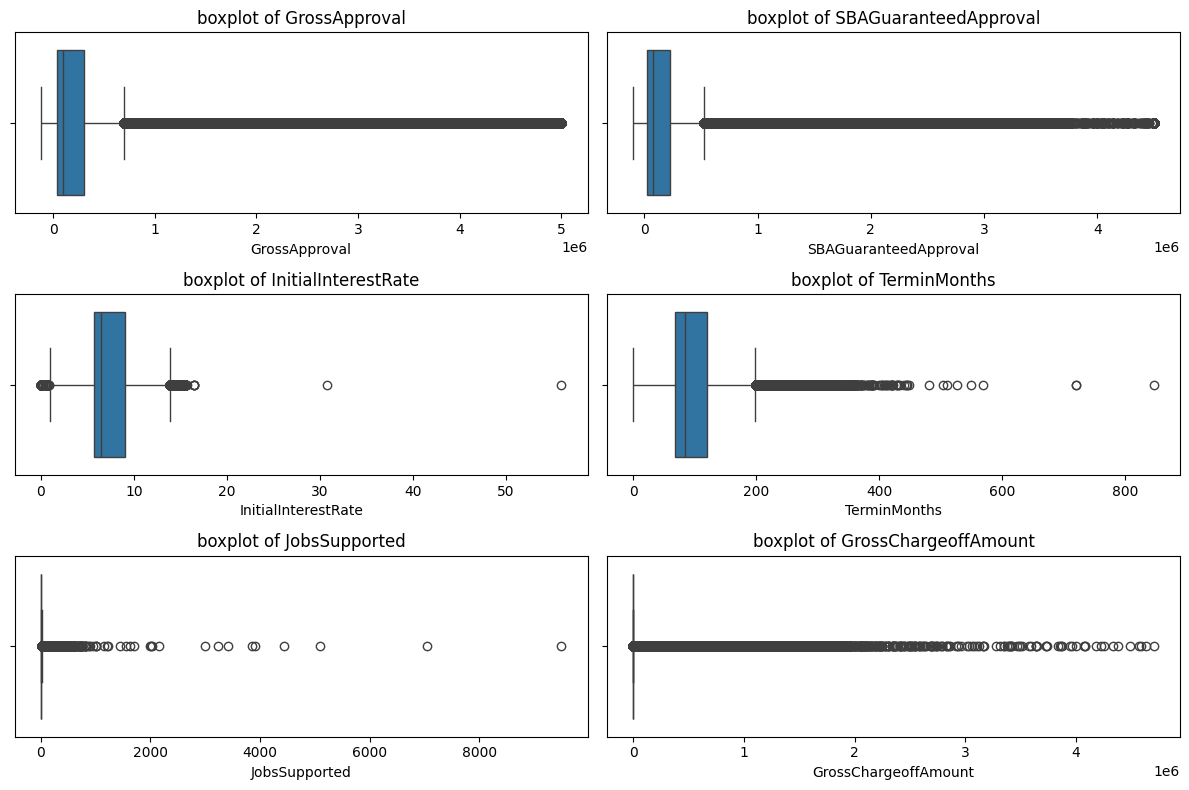


summary statistics for numeric variables:
       GrossApproval  SBAGuaranteedApproval  InitialInterestRate  \
count   1.902182e+06           1.902182e+06        929892.000000   
mean    3.024549e+05           2.242570e+05             7.352830   
std     5.696833e+05           4.366310e+05             2.353531   
min    -1.200000e+05          -9.600000e+04             0.000000   
1%      5.000000e+03           2.500000e+03             3.740000   
5%      1.000000e+04           5.000000e+03             4.500000   
50%     1.000000e+05           7.500000e+04             6.500000   
95%     1.287195e+06           9.652500e+05            11.500000   
99%     3.050000e+06           2.340000e+06            14.000000   
max     5.000000e+06           4.500000e+06            56.000000   

       TerminMonths  JobsSupported  GrossChargeoffAmount  
count  1.902187e+06   1.902185e+06          1.902187e+06  
mean   1.158333e+02   7.995544e+00          1.217823e+04  
std    7.678087e+01   2.173619e

In [ ]:
# outlier detection for key numeric variables

numeric_cols = [
    'GrossApproval',
    'SBAGuaranteedApproval',
    'InitialInterestRate',
    'TerminMonths',
    'JobsSupported',
    'GrossChargeoffAmount'
]

# boxplots to visualize outliers
loans_ = loans.reset_index(drop=True)
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x=loans_[col])
    plt.title(f'boxplot of {col}')
plt.tight_layout()
plt.show()

# print summary statistics
print("\nsummary statistics for numeric variables:")
print(loans[numeric_cols].describe(percentiles=[0.01, 0.05, 0.95, 0.99]))

# detect extreme outliers using IQR
outlier_report = {}
for col in numeric_cols:
    Q1 = loans[col].quantile(0.25)
    Q3 = loans[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((loans[col] < lower) | (loans[col] > upper)).mean()
    outlier_report[col] = outliers

print("\npercentage of outliers per variable:")
for col, pct in outlier_report.items():
    print(f"{col}: {pct:.4%}")

#2. **Data CleanUP**

### **Missing numeric values were imputed using the median, while missing categorical values were encoded as their own category**

In [ ]:
# create cleaned_loans from selected model features
cleaned_loans = loans.copy()

# numeric imputation (median)
numeric_cols = cleaned_loans.select_dtypes(include=['float64','int64']).columns
for col in numeric_cols:
    cleaned_loans[col] = cleaned_loans[col].fillna(cleaned_loans[col].median())

cleaned_loans.shape

(1902187, 45)

### **Filter cleaned_loans to keep only CHGOFF and PIF**

In [ ]:
cleaned_loans = cleaned_loans[
    cleaned_loans['LoanStatus'].isin(['CHGOFF', 'PIF'])
].copy()

cleaned_loans.shape

(1354286, 45)

In [ ]:
cleaned_loans.columns

Index(['AsOfDate', 'Program', 'BorrName', 'BorrStreet', 'BorrCity',
       'BorrState', 'BorrZip', 'LocationID', 'BankName', 'BankFDICNumber',
       'BankNCUANumber', 'BankStreet', 'BankCity', 'BankState', 'BankZip',
       'GrossApproval', 'SBAGuaranteedApproval', 'ApprovalDate', 'ApprovalFY',
       'FirstDisbursementDate', 'ProcessingMethod', 'Subprogram',
       'InitialInterestRate', 'FixedorVariableInterestRate', 'TerminMonths',
       'NAICSCode', 'NAICSDescription', 'FranchiseCode', 'FranchiseName',
       'ProjectCounty', 'ProjectState', 'SBADistrictOffice',
       'CongressionalDistrict', 'BusinessType', 'BusinessAge', 'LoanStatus',
       'PaidinFullDate', 'ChargeoffDate', 'GrossChargeoffAmount',
       'RevolverStatus', 'JobsSupported', 'CollateralInd',
       'SoldSecondMarketInd', 'NAICS2', 'is_default'],
      dtype='object')

# **Feature Engineering**

In [ ]:
# ensure default indicator
cleaned_loans['is_default'] = (cleaned_loans['LoanStatus'] == 'CHGOFF').astype(int)

# log-transform skewed numeric variables
cleaned_loans['Log_GrossApproval'] = np.log1p(cleaned_loans['GrossApproval'])
cleaned_loans['Log_SBAGuaranteedApproval'] = np.log1p(cleaned_loans['SBAGuaranteedApproval'])
cleaned_loans['Log_JobsSupported'] = np.log1p(cleaned_loans['JobsSupported'])
cleaned_loans['Log_GrossChargeoffAmount'] = np.log1p(cleaned_loans['GrossChargeoffAmount'])

# cap loan term outliers
cleaned_loans['TerminMonths_Capped'] = cleaned_loans['TerminMonths'].clip(lower=12, upper=360)

# convert date fields to numeric timestamps
date_cols = ['ApprovalDate', 'FirstDisbursementDate']
for col in date_cols:
    cleaned_loans[col + '_TimeStamp'] = (
        pd.to_datetime(cleaned_loans[col], errors='coerce').astype('int64') // 10**9
    )

# Add approval year as integer
cleaned_loans['ApprovalYear'] = pd.to_datetime(cleaned_loans['ApprovalDate'], errors='coerce').dt.year.astype('Int64')

cleaned_loans.columns

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Index(['AsOfDate', 'Program', 'BorrName', 'BorrStreet', 'BorrCity',
       'BorrState', 'BorrZip', 'LocationID', 'BankName', 'BankFDICNumber',
       'BankNCUANumber', 'BankStreet', 'BankCity', 'BankState', 'BankZip',
       'GrossApproval', 'SBAGuaranteedApproval', 'ApprovalDate', 'ApprovalFY',
       'FirstDisbursementDate', 'ProcessingMethod', 'Subprogram',
       'InitialInterestRate', 'FixedorVariableInterestRate', 'TerminMonths',
       'NAICSCode', 'NAICSDescription', 'FranchiseCode', 'FranchiseName',
       'ProjectCounty', 'ProjectState', 'SBADistrictOffice',
       'CongressionalDistrict', 'BusinessType', 'BusinessAge', 'LoanStatus',
       'PaidinFullDate', 'ChargeoffDate', 'GrossChargeoffAmount',
       'RevolverStatus', 'JobsSupported', 'CollateralInd',
       'SoldSecondMarketInd', 'NAICS2', 'is_default', 'Log_GrossApproval',
       'Log_SBAGuaranteedApproval', 'Log_JobsSupported',
       'Log_GrossChargeoffAmount', 'TerminMonths_Capped',
       'ApprovalDate_TimeStamp', 

In [ ]:
cleaned_loans.shape

(1354286, 53)

In [ ]:
# Save combined loan dataset to CSV
cleaned_loans.to_csv(path_gdrive + "/data/cleaned_loans_data.csv", index=False)
print('Cleaned data saved to drive successfully')

Cleaned data saved to drive successfully


### **Read data for Model**

In [ ]:
loans_df = pd.read_csv(path_gdrive + '/data/cleaned_loans_data.csv')
loans_df.columns

/tmp/ipython-input-941402826.py:1: DtypeWarning: Columns (7,10,14,23,27,34,43) have mixed types. Specify dtype option on import or set low_memory=False.
  loans_df = pd.read_csv(path_gdrive + '/data/cleaned_loans_data.csv')


Index(['AsOfDate', 'Program', 'BorrName', 'BorrStreet', 'BorrCity',
       'BorrState', 'BorrZip', 'LocationID', 'BankName', 'BankFDICNumber',
       'BankNCUANumber', 'BankStreet', 'BankCity', 'BankState', 'BankZip',
       'GrossApproval', 'SBAGuaranteedApproval', 'ApprovalDate', 'ApprovalFY',
       'FirstDisbursementDate', 'ProcessingMethod', 'Subprogram',
       'InitialInterestRate', 'FixedorVariableInterestRate', 'TerminMonths',
       'NAICSCode', 'NAICSDescription', 'FranchiseCode', 'FranchiseName',
       'ProjectCounty', 'ProjectState', 'SBADistrictOffice',
       'CongressionalDistrict', 'BusinessType', 'BusinessAge', 'LoanStatus',
       'PaidinFullDate', 'ChargeoffDate', 'GrossChargeoffAmount',
       'RevolverStatus', 'JobsSupported', 'CollateralInd',
       'SoldSecondMarketInd', 'NAICS2', 'is_default', 'Log_GrossApproval',
       'Log_SBAGuaranteedApproval', 'Log_JobsSupported',
       'Log_GrossChargeoffAmount', 'TerminMonths_Capped',
       'ApprovalDate_TimeStamp', 

### **Year wise data distribution**

In [ ]:
loans_2008 = loans_df[loans_df['ApprovalYear'] == 2008]
loans_2008.shape[0]

50287

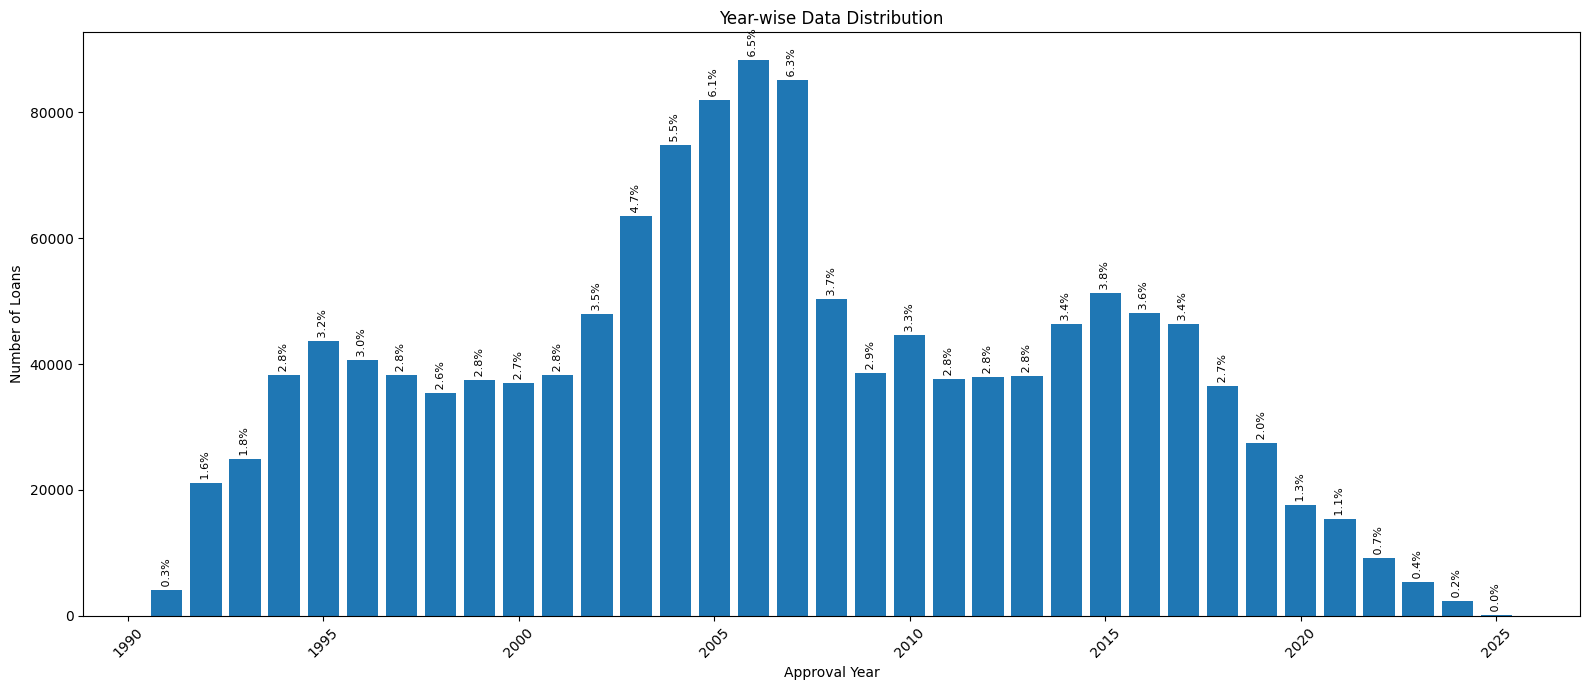

In [ ]:
# year-wise counts
year_counts = loans_df['ApprovalYear'].value_counts().sort_index()

# convert to percentages
year_percent = (year_counts / year_counts.sum()) * 100

# expanded figure size
plt.figure(figsize=(16, 7))  # ⬅️ wider and taller

bars = plt.bar(year_counts.index, year_counts.values)

plt.xlabel("Approval Year")
plt.ylabel("Number of Loans")
plt.title("Year-wise Data Distribution")

# add % labels on top of each bar
for bar, pct in zip(bars, year_percent.values):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f" {pct:.1f}%",
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=90
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

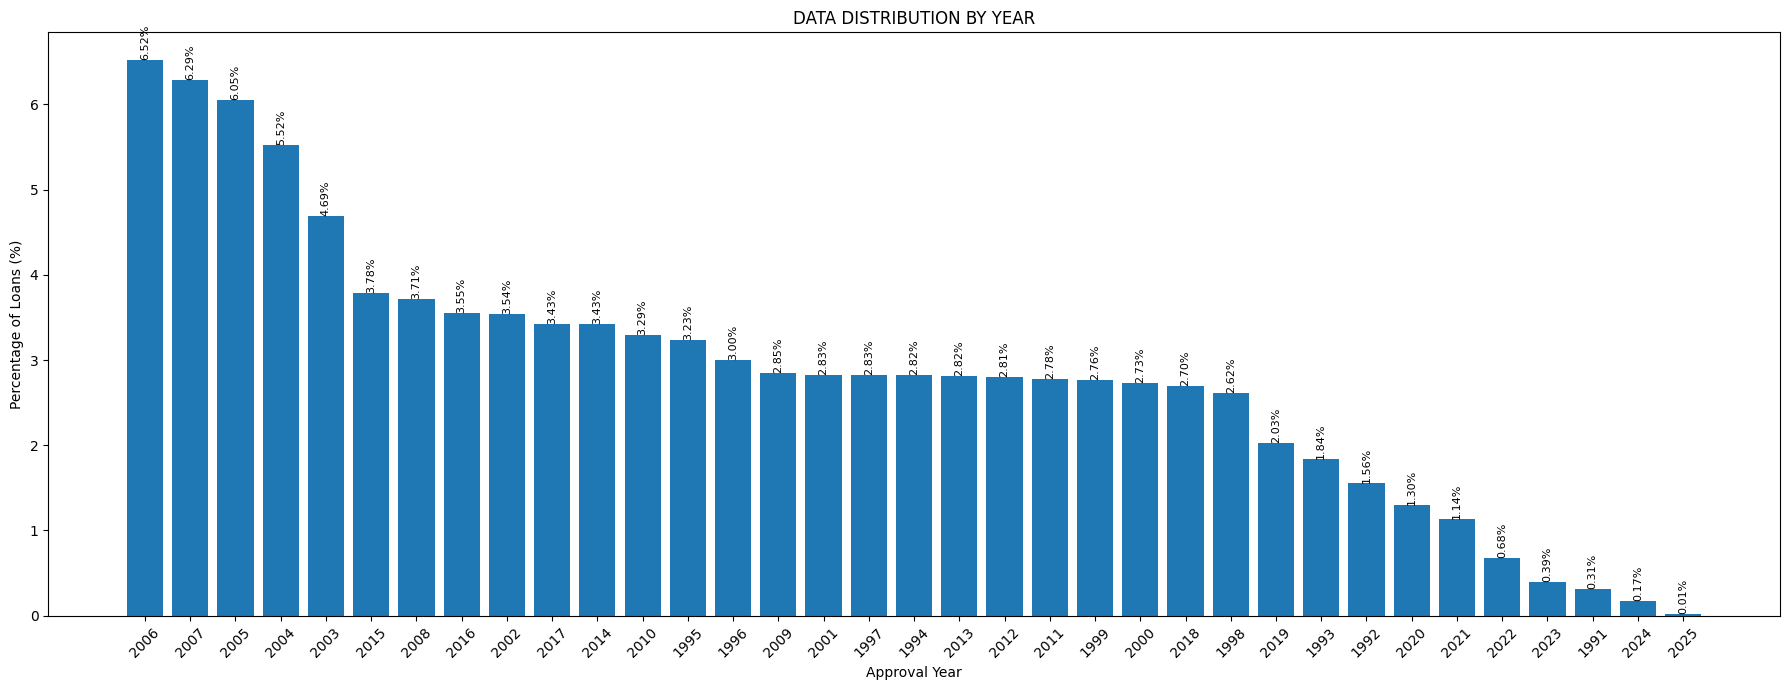

In [ ]:
# year-wise counts
year_counts = loans_df['ApprovalYear'].value_counts()

# convert to percentages
year_percent = (year_counts / year_counts.sum()) * 100

# sort by percentage descending
year_percent_sorted = year_percent.sort_values(ascending=False)

# expanded figure size
plt.figure(figsize=(18, 7))

bars = plt.bar(year_percent_sorted.index.astype(str), year_percent_sorted.values)

plt.xlabel("Approval Year")
plt.ylabel("Percentage of Loans (%)")
plt.title("DATA DISTRIBUTION BY YEAR")

# add % labels on top of each bar
for bar, pct in zip(bars, year_percent_sorted.values):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{pct:.2f}%",
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=90
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**TOP 10**

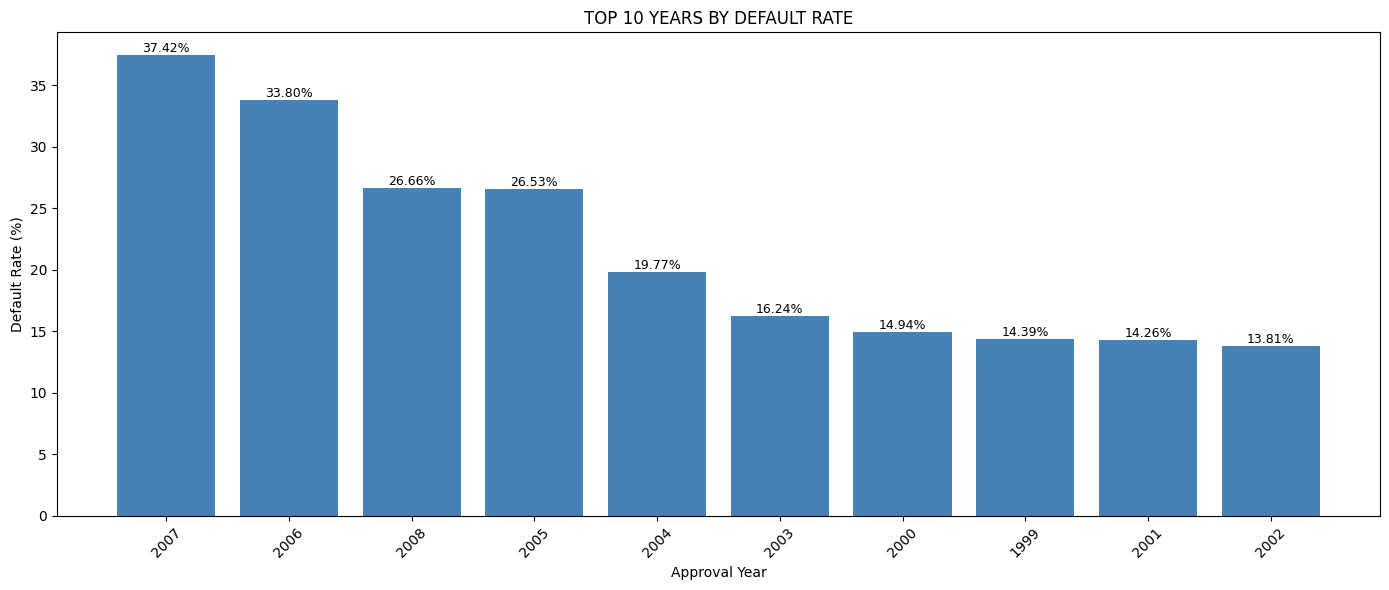

In [ ]:
# compute default rate per year (%)
default_rate_by_year = (
    loans_df
    .groupby('ApprovalYear')['is_default']
    .mean() * 100
)

# sort by default rate descending and take top 10
top10_default_years = default_rate_by_year.sort_values(ascending=False).head(10)

# expanded figure size
plt.figure(figsize=(14, 6))

bars = plt.bar(
    top10_default_years.index.astype(str),
    top10_default_years.values,
    color='steelblue'   # ✅ custom color applied
)

plt.xlabel("Approval Year")
plt.ylabel("Default Rate (%)")
plt.title("TOP 10 YEARS BY DEFAULT RATE")

# add % labels on top of each bar
for bar, pct in zip(bars, top10_default_years.values):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{pct:.2f}%",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Default rate by industry and business type**

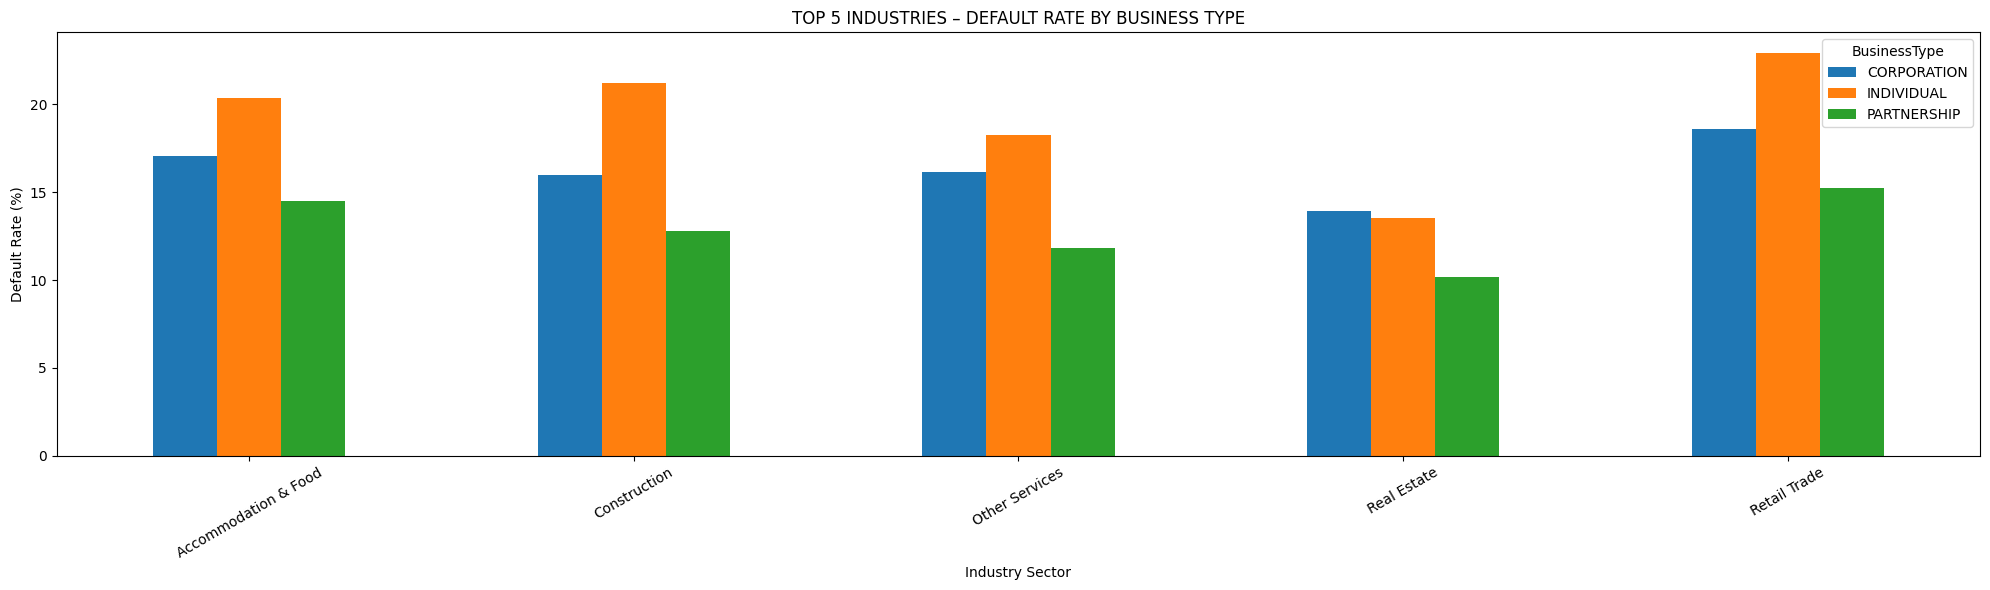

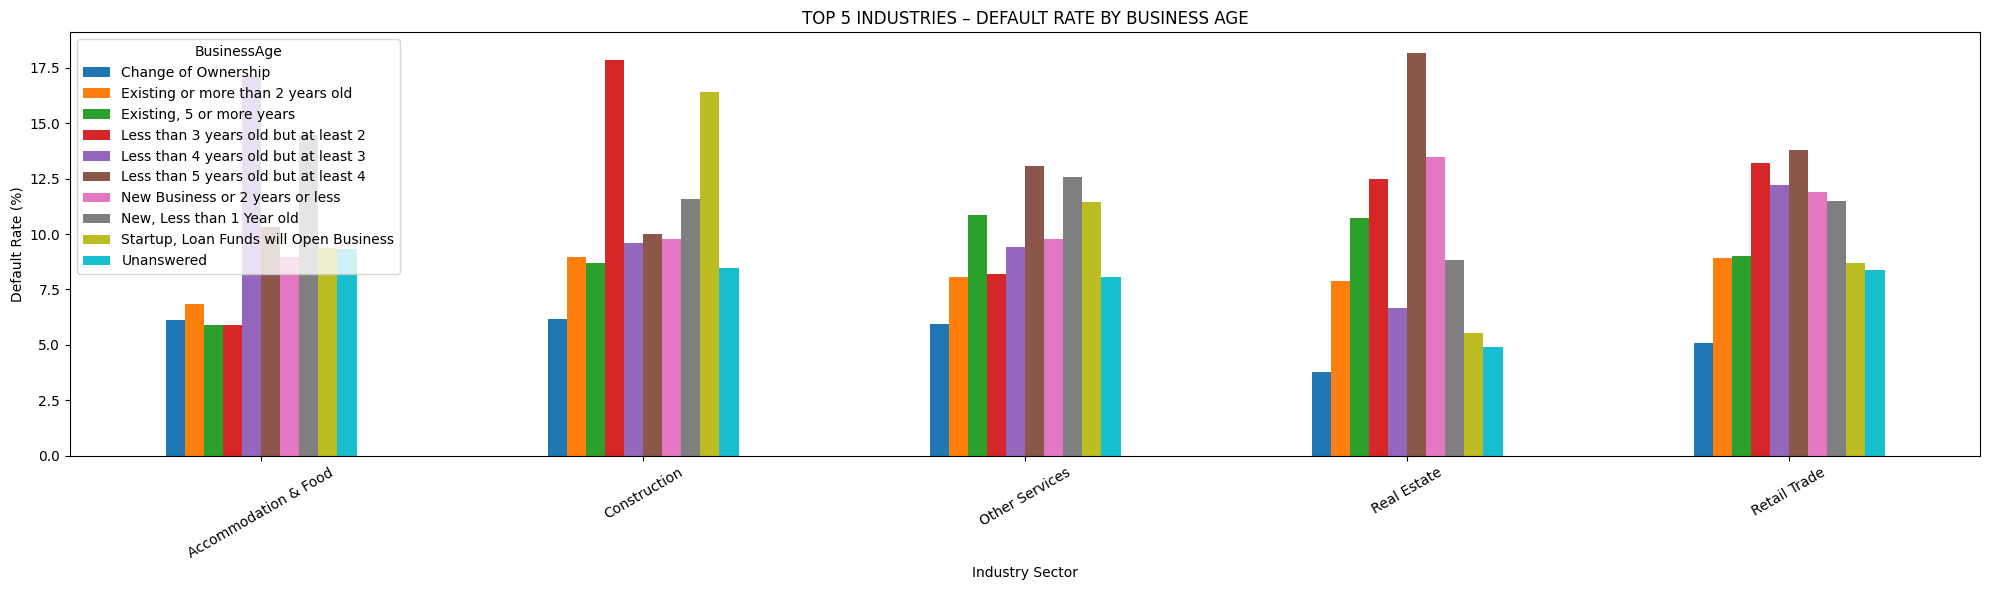

In [ ]:
import matplotlib.pyplot as plt

# -------------------------------
# NAICS2 → Industry Name Lookup
# -------------------------------
naics2_lookup = {
    '11': 'Agriculture',
    '21': 'Mining',
    '22': 'Utilities',
    '23': 'Construction',
    '31': 'Manufacturing',
    '32': 'Manufacturing',
    '33': 'Manufacturing',
    '42': 'Wholesale Trade',
    '44': 'Retail Trade',
    '45': 'Retail Trade',
    '48': 'Transportation',
    '49': 'Transportation',
    '51': 'Information',
    '52': 'Finance & Insurance',
    '53': 'Real Estate',
    '54': 'Professional Services',
    '55': 'Management',
    '56': 'Administrative Services',
    '61': 'Education',
    '62': 'Health Care',
    '71': 'Arts & Entertainment',
    '72': 'Accommodation & Food',
    '81': 'Other Services',
    '92': 'Public Administration'
}

# -------------------------------
# Create NAICS2 and Industry Name
# -------------------------------
loans_df['NAICS2'] = loans_df['NAICSCode'].astype(str).str[:2]
loans_df['Industry'] = loans_df['NAICS2'].map(naics2_lookup)

# -------------------------------
# Keep Only 3 Business Types
# -------------------------------
valid_types = ['CORPORATION', 'INDIVIDUAL', 'PARTNERSHIP']
loans_df = loans_df[loans_df['BusinessType'].isin(valid_types)]

# -------------------------------
# Select Top 5 Industries
# -------------------------------
top5_industries = loans_df['Industry'].value_counts().head(5).index
temp = loans_df[loans_df['Industry'].isin(top5_industries)]

# ======================================================
# ✅ GRAPH 1: TOP 5 × BUSINESS TYPE
# ======================================================

grouped_bt = (
    temp
    .groupby(['Industry', 'BusinessType'])['is_default']
    .mean()
    .reset_index()
)

pivot_bt = grouped_bt.pivot(
    index='Industry',
    columns='BusinessType',
    values='is_default'
) * 100

fig, ax = plt.subplots(figsize=(20, 6))
pivot_bt.plot(kind='bar', ax=ax)

ax.set_xlabel("Industry Sector")
ax.set_ylabel("Default Rate (%)")
ax.set_title("TOP 5 INDUSTRIES – DEFAULT RATE BY BUSINESS TYPE")
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# ======================================================
# ✅ GRAPH 2: TOP 5 × BUSINESS AGE
# ======================================================

grouped_ba = (
    temp
    .groupby(['Industry', 'BusinessAge'])['is_default']
    .mean()
    .reset_index()
)

pivot_ba = grouped_ba.pivot(
    index='Industry',
    columns='BusinessAge',
    values='is_default'
) * 100

fig, ax = plt.subplots(figsize=(20, 6))
pivot_ba.plot(kind='bar', ax=ax)

ax.set_xlabel("Industry Sector")
ax.set_ylabel("Default Rate (%)")
ax.set_title("TOP 5 INDUSTRIES – DEFAULT RATE BY BUSINESS AGE")
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

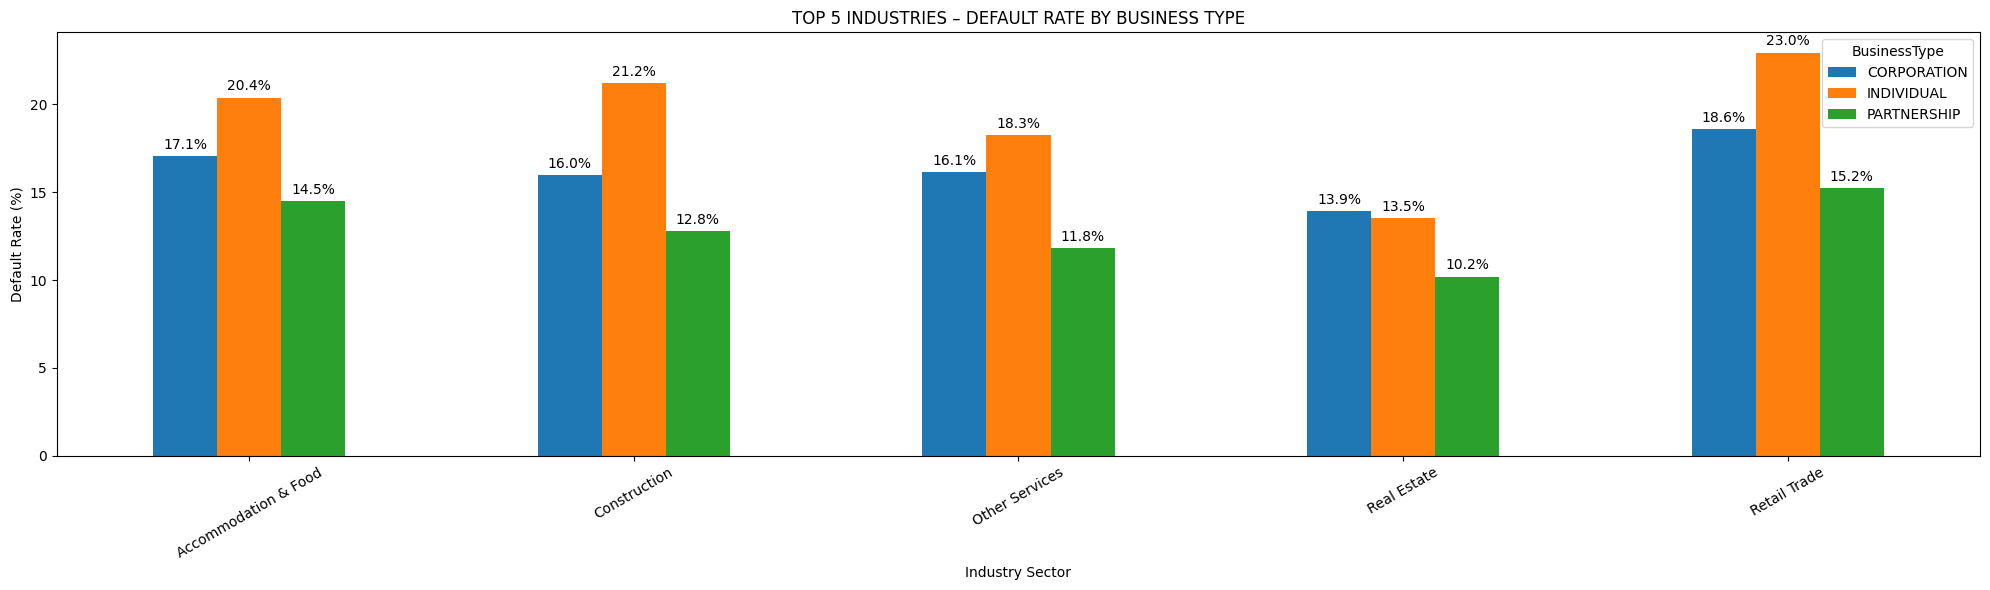

In [ ]:
import matplotlib.pyplot as plt

# -------------------------------
# NAICS2 → Industry Name Lookup
# -------------------------------
naics2_lookup = {
    '11': 'Agriculture',
    '21': 'Mining',
    '22': 'Utilities',
    '23': 'Construction',
    '31': 'Manufacturing',
    '32': 'Manufacturing',
    '33': 'Manufacturing',
    '42': 'Wholesale Trade',
    '44': 'Retail Trade',
    '45': 'Retail Trade',
    '48': 'Transportation',
    '49': 'Transportation',
    '51': 'Information',
    '52': 'Finance & Insurance',
    '53': 'Real Estate',
    '54': 'Professional Services',
    '55': 'Management',
    '56': 'Administrative Services',
    '61': 'Education',
    '62': 'Health Care',
    '71': 'Arts & Entertainment',
    '72': 'Accommodation & Food',
    '81': 'Other Services',
    '92': 'Public Administration'
}

# -------------------------------
# Create NAICS2 and Industry Name
# -------------------------------
loans_df['NAICS2'] = loans_df['NAICSCode'].astype(str).str[:2]
loans_df['Industry'] = loans_df['NAICS2'].map(naics2_lookup)

# -------------------------------
# Keep Only 3 Business Types
# -------------------------------
valid_types = ['CORPORATION', 'INDIVIDUAL', 'PARTNERSHIP']
loans_df = loans_df[loans_df['BusinessType'].isin(valid_types)]

# -------------------------------
# Select Top 5 Industries
# -------------------------------
top5_industries = loans_df['Industry'].value_counts().head(5).index
temp = loans_df[loans_df['Industry'].isin(top5_industries)]

# -------------------------------
# Compute Default Rate
# -------------------------------
grouped_bt = (
    temp
    .groupby(['Industry', 'BusinessType'])['is_default']
    .mean()
    .reset_index()
)

pivot_bt = grouped_bt.pivot(
    index='Industry',
    columns='BusinessType',
    values='is_default'
) * 100

# -------------------------------
# ✅ PLOT WITH % LABELS
# -------------------------------
fig, ax = plt.subplots(figsize=(20, 6))
pivot_bt.plot(kind='bar', ax=ax)

ax.set_xlabel("Industry Sector")
ax.set_ylabel("Default Rate (%)")
ax.set_title("TOP 5 INDUSTRIES – DEFAULT RATE BY BUSINESS TYPE")
ax.tick_params(axis='x', rotation=30)

# ✅ ADD % LABELS ON EACH BAR
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

---

# **MODEL**

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

from mlxtend.feature_selection import SequentialFeatureSelector as SFS

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score, accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay


In [ ]:
file_path = path_gdrive + "data/cleaned_loans_data.csv"

loan_df = pd.read_csv(file_path)
loan_df.columns

/tmp/ipython-input-1150704068.py:3: DtypeWarning: Columns (7,10,14,23,27,34,43) have mixed types. Specify dtype option on import or set low_memory=False.
  loan_df = pd.read_csv(file_path)


Index(['AsOfDate', 'Program', 'BorrName', 'BorrStreet', 'BorrCity',
       'BorrState', 'BorrZip', 'LocationID', 'BankName', 'BankFDICNumber',
       'BankNCUANumber', 'BankStreet', 'BankCity', 'BankState', 'BankZip',
       'GrossApproval', 'SBAGuaranteedApproval', 'ApprovalDate', 'ApprovalFY',
       'FirstDisbursementDate', 'ProcessingMethod', 'Subprogram',
       'InitialInterestRate', 'FixedorVariableInterestRate', 'TerminMonths',
       'NAICSCode', 'NAICSDescription', 'FranchiseCode', 'FranchiseName',
       'ProjectCounty', 'ProjectState', 'SBADistrictOffice',
       'CongressionalDistrict', 'BusinessType', 'BusinessAge', 'LoanStatus',
       'PaidinFullDate', 'ChargeoffDate', 'GrossChargeoffAmount',
       'RevolverStatus', 'JobsSupported', 'CollateralInd',
       'SoldSecondMarketInd', 'NAICS2', 'is_default', 'Log_GrossApproval',
       'Log_SBAGuaranteedApproval', 'Log_JobsSupported',
       'Log_GrossChargeoffAmount', 'TerminMonths_Capped',
       'ApprovalDate_TimeStamp', 

In [ ]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1354286 entries, 0 to 1354285
Data columns (total 53 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   AsOfDate                         1354286 non-null  object 
 1   Program                          1354286 non-null  object 
 2   BorrName                         1354263 non-null  object 
 3   BorrStreet                       1354216 non-null  object 
 4   BorrCity                         1354284 non-null  object 
 5   BorrState                        1354286 non-null  object 
 6   BorrZip                          1354286 non-null  int64  
 7   LocationID                       1349475 non-null  object 
 8   BankName                         1354286 non-null  object 
 9   BankFDICNumber                   1354286 non-null  float64
 10  BankNCUANumber                   27400 non-null    object 
 11  BankStreet                       1349477 non-null 

In [ ]:
relevant_cols = [
    "BorrState",
    "BankName",
    # "BankState",
    # "GrossApproval",
    # "SBAGuaranteedApproval",
    # "ApprovalDate",
    "ProcessingMethod",
    "Subprogram",
    "InitialInterestRate",
    "FixedorVariableInterestRate",
    # "TerminMonths",
    # "NAICSCode",
    # "NAICSDescription",
    # "FranchiseCode",
    "FranchiseName",
    # "ProjectState",
    "BusinessType",
    "BusinessAge",
    "RevolverStatus",
    # "JobsSupported",
    "CollateralInd",
    "SoldSecondMarketInd",
    "NAICS2",
    "Log_GrossApproval",
    # "Log_SBAGuaranteedApproval",
    "Log_JobsSupported",
    "TerminMonths_Capped",
    # "ApprovalDate_TimeStamp",
    # "FirstDisbursementDate_TimeStamp",
    "ApprovalYear"
]

datadict = []

for col in relevant_cols:
    unique_vals = loan_df[col].value_counts()
    datadict.append({
        'column': col,
        'dtype': loan_df[col].dtype,
        'num_unique': loan_df[col].nunique(),
        'unique': unique_vals.values.tolist()[:15],
        'first_15_unique_vals': unique_vals.index.tolist()[:15]
    })
pd.set_option('display.max_colwidth', None)
datadict_df = pd.DataFrame(datadict)

display(datadict_df)

,column,dtype,num_unique,unique,first_15_unique_vals
0,BorrState,object,62,"[179125, 107913, 87263, 64284, 57634, 51377, 43878, 41925, 39543, 38561, 36718, 35195, 34351, 32310, 31547]","[CA, TX, NY, FL, OH, PA, IL, MA, MI, NJ, MN, WA, GA, WI, CO]"
1,BankName,object,4899,"[100678, 87984, 78440, 60098, 49931, 47921, 41838, 35166, 30505, 25062, 24959, 21094, 19880, 18651, 18154]","[Wells Fargo Bank National Association, Bank of America, National Association, JPMorgan Chase Bank, National Association, U.S. Bank, National Association, PNC Bank, National Association, The Huntington National Bank, Citizens Bank, National Association, Bank of Hope, Manufacturers and Traders Trust Company, Zions Bank, A Division of, TD Bank, National Association, Capital One, National Association, Truist Bank, KeyBank National Association, Columbia Bank]"
2,ProcessingMethod,object,30,"[585683, 329619, 162235, 124553, 46329, 43124, 24606, 9616, 4496, 4482, 3653, 3417, 2824, 2820, 2359]","[SBA Express Program, Preferred Lenders Program, 7a General, Low Documentation Program, Certified Lenders Program, Community Express, Small Loan Advantage Initiative, Patriot Express Loans, International Trade Loans, Community Advantage Initiative, Rural Loan Initiative, 7a with EWCP, Gulf Opportunity Pilot Loan Program, Standard Asset Base Working Capital Line of Credit (CAPLine), Export Express]"
3,Subprogram,object,18,"[662736, 588043, 43124, 24606, 9616, 4860, 4510, 4504, 3653, 2824, 2820, 1031, 749, 571, 472]","[Guaranty, FA$TRK (Small Loan Express), Community Express, Lender Advantage Initiative, Patriot Express, Revolving Line of Credit Exports - Sec. 7(a) (14), Community Advantage Initiative, International Trade - Sec, 7(a) (16), Rural Lender Advantage, Gulf Opportunity, Standard Asset Based, Contract Guaranty, Small Asset Based, Small General Contractors - Sec. 7(a) (9), Seasonal Line of Credit]"
4,InitialInterestRate,float64,1869,"[864134, 79328, 34291, 32015, 27721, 22539, 18409, 17415, 17145, 13689, 13385, 13204, 13067, 12683, 10031]","[6.5, 6.0, 5.5, 5.25, 5.75, 6.25, 7.75, 7.0, 5.0, 4.75, 6.75, 9.75, 7.25, 7.5, 8.0]"
5,FixedorVariableInterestRate,object,2,"[400828, 106218]","[V, F]"
6,FranchiseName,object,6613,"[4028, 2199, 1110, 1018, 855, 822, 632, 615, 560, 520, 517, 491, 444, 430, 419]","[SUBWAY SANDWICH SHOP , QUIZNOS , MAIL BOXES ETC. USA , DAIRY QUEEN , DUNKIN DONUTS , COLD STONE CREAMERY, INC. , MATCO TOOLS (RENT TOOLS) , DOMINO'S PIZZA , DAYS INN , BLIMPIE, SUPER 8 MOTEL , SUBWAY, SPORTS CLIPS , BASKIN-ROBBINS 31 ICE CREAM , CURVES FOR WOMEN ]"
7,BusinessType,object,4,"[1016513, 291855, 42556, 3362]","[CORPORATION, INDIVIDUAL, PARTNERSHIP, ]"
8,BusinessAge,object,10,"[61672, 19172, 14654, 11220, 9043, 4907, 1680, 852, 700, 590]","[Existing or more than 2 years old, Startup, Loan Funds will Open Business, Unanswered, Change of Ownership, New Business or 2 years or less, Existing, 5 or more years, New, Less than 1 Year old, Less than 3 years old but at least 2, Less than 4 years old but at least 3, Less than 5 years old but at least 4]"
9,RevolverStatus,int64,2,"[1020151, 334135]","[0, 1]"


In [ ]:
# BorrState has more than 50 values; need to check
# BusinessType should be not have blank values
# SoldSecondMarketInd should only have 'Y' and 'N' values
# NAICS2 should not have 'na' values
# RevolverStatus needs to be categorical

loan_df = loan_df[loan_df["BusinessType"].str.strip() != ""]
loan_df['SoldSecondMarketInd'] = loan_df['SoldSecondMarketInd'].replace(r'^\s*$', np.nan, regex=True)
loan_df = loan_df[loan_df["BorrState"].str.strip() != ""]
loan_df['NAICS2'] = loan_df['NAICS2'].replace('na', np.nan, regex=True)
loan_df.loc[:, 'RevolverStatus'] = loan_df['RevolverStatus'].astype('category')

state_codes = [
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA", "HI", "ID", "IL",
    "IN", "IA", "KS", "KY", "LA", "ME", "MD", "MA", "MI", "MN", "MS", "MO", "MT",
    "NE", "NV", "NH", "NJ", "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI",
    "SC", "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY"
]

# also print the counts of the unique states not in state_codes
unique_states = loan_df["BorrState"].value_counts()
for state in unique_states.index:
    if state not in state_codes:
        print(state, unique_states[state])

PR 15526
DC 2377
GU 964
VI 361
MP 27
AS 12
PW 7
MH 3
AE 2
TQ 1
FM 1


PR: Puerto Rico  
DC: District of Columbia  
GU: Guam  
VI: U.S. Virgin Islands  
MP: Northern Mariana Islands  
AS: American Samoa  
PW: Palau  
MH: Marshall Islands  

AE, TQ, and FM may be military postal codes; but will remove due to low values (potential typos).

In [ ]:
# remove rows that have AE, TQ, FM in BorrState
loan_df = loan_df[~loan_df["BorrState"].isin(["AE", "TQ", "FM"])]

In [ ]:
# assign NAICS2 codes to correct categories using lookup table

naics_lookup = {
    11: "Agriculture, Forestry, Fishing and Hunting",
    21: "Mining, Quarrying, and Oil and Gas Extraction",
    22: "Utilities",
    23: "Construction",
    31: "Manufacturing",
    32: "Manufacturing",
    33: "Manufacturing",
    42: "Wholesale Trade",
    44: "Retail Trade",
    45: "Retail Trade",
    48: "Transportation and Warehousing",
    49: "Transportation and Warehousing",
    51: "Information",
    52: "Finance and Insurance",
    53: "Real Estate and Rental and Leasing",
    54: "Professional, Scientific, and Technical Services",
    55: "Management of Companies and Enterprises",
    56: "Administrative and Support and Waste Management",
    61: "Educational Services",
    62: "Health Care and Social Assistance",
    71: "Arts, Entertainment, and Recreation",
    72: "Accommodation and Food Services",
    81: "Other Services (except Public Administration)",
    92: "Public Administration"
}

loan_df['NAICS2'] = loan_df['NAICS2'].map(naics_lookup)

feature selection

In [ ]:
# get certain years; and years should NOT be numerical
years = [2008]
loan_df_ = loan_df[loan_df["ApprovalYear"].isin(years)]
loan_df_.loc[:, 'ApprovalYear'] = loan_df_['ApprovalYear'].astype('category')

loan_df_["is_default"].value_counts()

,count
is_default,
0,36866
1,13397


In [ ]:
# relevant X columns
loan_df_x = loan_df_[relevant_cols]

# BankName and FranchiseName will create too many dummies
# for ALL dummies, create 'other' category that combines all categories
#  that take up less than low_p proportion of the data
low_p = 0.01

for cat_col in loan_df_x.select_dtypes(exclude='number').columns:
  # print(loan_df_x[cat_col].value_counts())
  count0 = loan_df_x[cat_col].nunique()
  top = loan_df_x[cat_col].value_counts()/loan_df_x.shape[0]
  top_names = top[top>=low_p].index
  loan_df_x.loc[~loan_df_x[cat_col].isin(top_names), cat_col] = "Other"
  print(f"{cat_col}: {count0} -> {loan_df_x[cat_col].nunique()} categories")

# create dummy columns for categorical columns
loan_df_x = pd.get_dummies(loan_df_x, drop_first=True, dtype=np.uint8)

# just in case, remove constant columns
loan_df_x = loan_df_x.loc[:, loan_df_x.nunique() > 1]
print(f"Features: {loan_df_x.shape[1]}")

BorrState: 54 -> 30 categories
BankName: 1399 -> 19 categories
ProcessingMethod: 16 -> 6 categories
Subprogram: 14 -> 5 categories
FixedorVariableInterestRate: 2 -> 3 categories
FranchiseName: 721 -> 1 categories
BusinessType: 3 -> 3 categories
BusinessAge: 0 -> 1 categories
CollateralInd: 2 -> 2 categories
SoldSecondMarketInd: 2 -> 2 categories
NAICS2: 20 -> 16 categories
Features: 82


In [ ]:
# feature selection
y = loan_df_["is_default"]
X = loan_df_x

# test train split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train shape:", X_train.shape, "\nTest shape:", X_test.shape)

Train shape: (40210, 82) 
Test shape: (10053, 82)


---

In [ ]:
# BIC-based scorer for feature selection
def calculate_bic(estimator, X, y):
    y_pred_proba = estimator.predict_proba(X)[:, 1]

    # log-likelihood
    n = len(y)
    k = X.shape[1]
    y_pred_proba = np.clip(y_pred_proba, 1e-15, 1 - 1e-15)
    log_likelihood = np.sum(y * np.log(y_pred_proba) + (1 - y) * np.log(1 - y_pred_proba))

    bic = -2 * log_likelihood + k * np.log(n)

    return -1*bic # NEGATIVE so SFS maximizes it (lower BIC = better)

In [ ]:
# sklearn logistic regression model
model = LogisticRegression(max_iter=10000, class_weight='balanced')

# Sequential Feature Selection with Logistic Regression
sfs = SFS(
    model,
    k_features=(1,40), # limit the features for faster computation
    forward=True,
    floating=False,
    scoring=lambda estimator, X, y: calculate_bic(estimator, X, y),
    cv=5,
    n_jobs=-1, # use all available cores
    verbose=1
)

sfs = sfs.fit(X_train, y_train)

selected_features = list(sfs.k_feature_names_)
print("\nSelected features:", selected_features)



# analyze the other feature groups
feature_groups = sfs.subsets_
for key in feature_groups.keys():
    print(f"Feature group {key}:")
    print("  Features:", feature_groups[key]['feature_names'])
    print("  CV Score:", feature_groups[key]['avg_score'])

SyntaxError: invalid syntax (ipython-input-3510539456.py, line 2)

Since stepwise selection takes a long time, here is the output:

In [ ]:
selected_features = [
    'Log_GrossApproval',
    'TerminMonths_Capped',
    'ProcessingMethod_Community Express',
    'Subprogram_Guaranty',

    'Log_JobsSupported', # added, should be important
    'NAICS2_Health Care and Social Assistance',
    'NAICS2_Retail Trade',
    'BorrState_CA',
    'BorrState_FL',

    'BankName_Capital One, National Association',
    'BankName_KeyBank National Association',
    'BankName_Manufacturers and Traders Trust Company',
    'BankName_Mountain America FCU',
    'BankName_Other',
    'BankName_Popular Bank',
    'BankName_VelocitySBA, LLC',
    # 'FixedorVariableInterestRate_Other', removed; not meaningful
    'SoldSecondMarketInd_Y',
]

In [ ]:
X_train_sm = sm.add_constant(X_train[selected_features])
X_test_sm = sm.add_constant(X_test[selected_features])

model = sm.GLM(
    y_train,
    X_train_sm,
    family=sm.families.Binomial()
).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             is_default   No. Observations:                40210
Model:                            GLM   Df Residuals:                    40192
Model Family:                Binomial   Df Model:                           17
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -19466.
Date:                Mon, 08 Dec 2025   Deviance:                       38933.
Time:                        21:47:37   Pearson chi2:                 7.54e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1747
Covariance Type:            nonrobust                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------

In [ ]:
table = {
    "Predictor":model.params,
    "Odds Ratio": np.exp(model.params),
    "inc/dec": np.where(model.params > 0, "inc", "dec"),
    "percentage_change": (np.exp(model.params)-1)*100,
}

pd.DataFrame(table)

,Predictor,Odds Ratio,inc/dec,percentage_change
const,-2.252567,0.105129,dec,-89.487101
Log_GrossApproval,0.276469,1.318466,inc,31.846576
TerminMonths_Capped,-0.025025,0.975286,dec,-2.471410
ProcessingMethod_Community Express,0.545383,1.725270,inc,72.526976
Subprogram_Guaranty,0.684905,1.983583,inc,98.358327
Log_JobsSupported,-0.079506,0.923572,dec,-7.642797
NAICS2_Health Care and Social Assistance,-0.493527,0.610469,dec,-38.953073
NAICS2_Retail Trade,0.188718,1.207700,inc,20.770027
BorrState_CA,0.256843,1.292842,inc,29.284213
BorrState_FL,0.603683,1.828842,inc,82.884175


In [ ]:
y_pred_prob = model.predict(X_test_sm)
y_pred = (y_pred_prob > 0.43).astype(int)

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Accuracy: 0.7891
ROC AUC: 0.7954


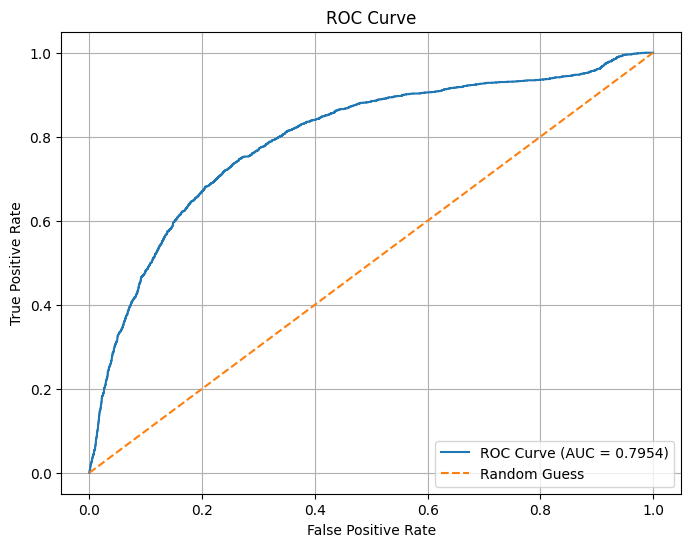

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

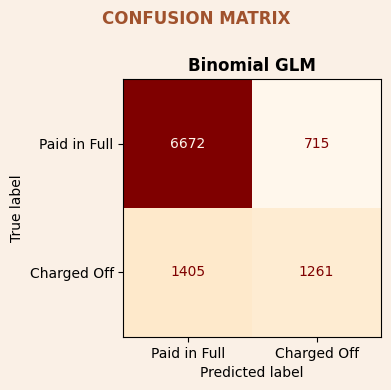

In [ ]:
cm_disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=["Paid in Full","Charged Off"]
)

fig,ax = plt.subplots(1,1,figsize=(4,4))
fig.suptitle("CONFUSION MATRIX", weight="bold", color="sienna")
fig.set_facecolor("linen")

ax.set_title("Binomial GLM",weight="bold")
cm_disp.plot(ax=ax,cmap="OrRd",colorbar=False)

plt.tight_layout()
plt.show()

## Testing with Other Years

Final Aligned 2012 Features Shape (with constant): (37992, 18)

Prediction Results for 2012
Accuracy: 0.9216
ROC AUC: 0.8138
Final Aligned 2014 Features Shape (with constant): (46402, 18)

Prediction Results for 2014
Accuracy: 0.9232
ROC AUC: 0.8121
Final Aligned 2007 Features Shape (with constant): (85161, 18)

Prediction Results for 2007
Accuracy: 0.6449
ROC AUC: 0.7808
Final Aligned 2005 Features Shape (with constant): (81969, 18)

Prediction Results for 2005
Accuracy: 0.7582
ROC AUC: 0.8125
Final Aligned 1998 Features Shape (with constant): (35210, 18)

Prediction Results for 1998
Accuracy: 0.8598
ROC AUC: 0.7544


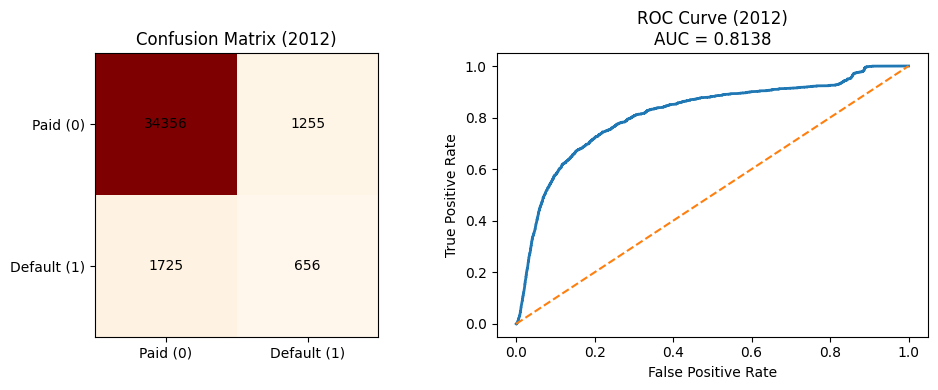

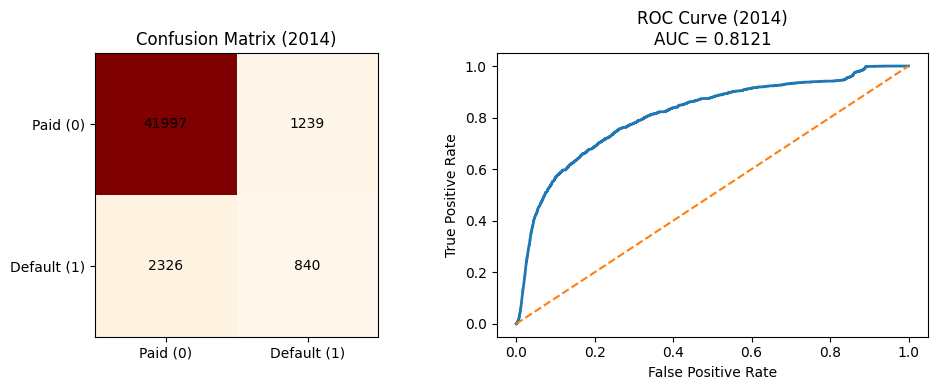

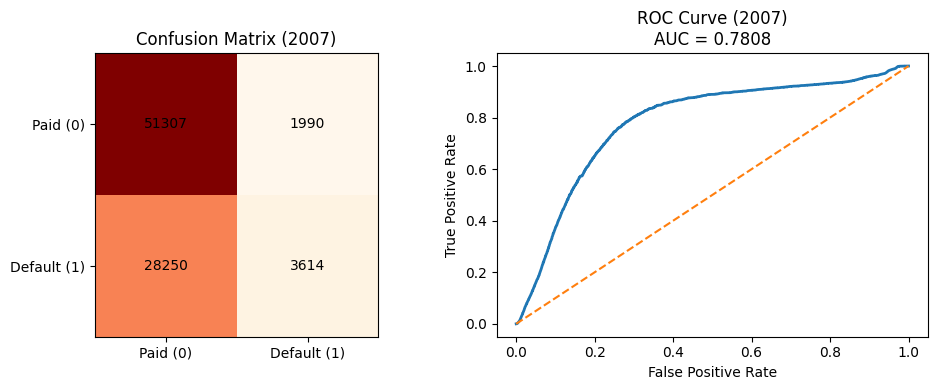

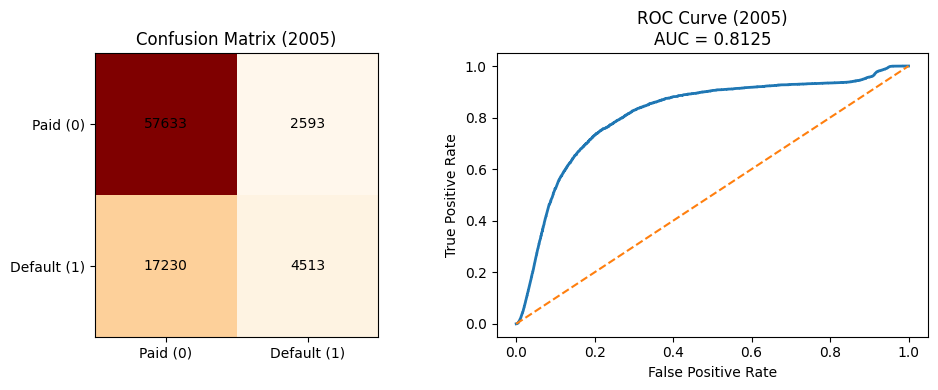

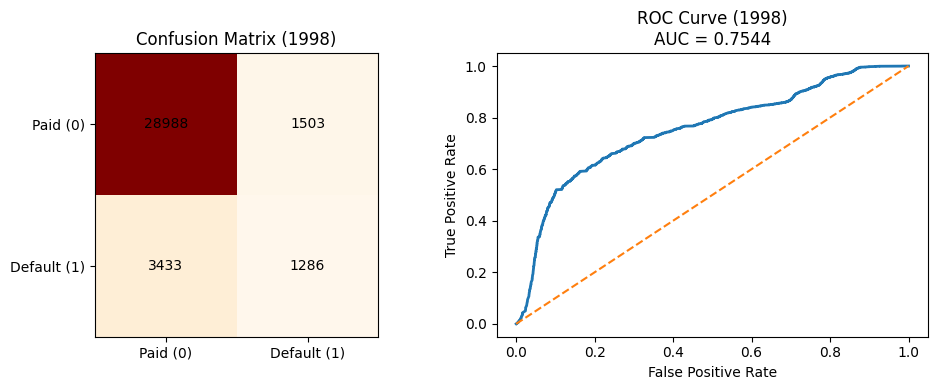

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve
import statsmodels.api as sm

years_test = [2012, 2014, 2007, 2005, 1998]
low_p = 0.01

for year in years_test:
    loan_df_year = loan_df[loan_df["ApprovalYear"] == year].copy()
    if loan_df_year.empty:
        print(f"No data for year {year}, skipping.")
        continue

    loan_df_year['ApprovalYear'] = loan_df_year['ApprovalYear'].astype('category')
    X_year = loan_df_year[relevant_cols].copy()
    y_year = loan_df_year["is_default"].copy()

    # --- CLEAN CATEGORICALS ---
    for cat_col in X_year.select_dtypes(exclude='number').columns:
        if isinstance(X_year[cat_col].dtype, pd.CategoricalDtype):
            if "Other" not in X_year[cat_col].cat.categories:
                X_year[cat_col] = X_year[cat_col].cat.add_categories("Other")

        top_names = X_year[cat_col].value_counts(normalize=True).loc[lambda x: x >= low_p].index
        X_year.loc[~X_year[cat_col].isin(top_names), cat_col] = "Other"

        if X_year[cat_col].dtype == object:
            X_year[cat_col] = X_year[cat_col].str.strip()

    # --- ONE-HOT ---
    X_year_encoded = pd.get_dummies(X_year, drop_first=True, dtype=np.uint8, prefix_sep="__")

    if X_year_encoded.columns.duplicated().any():
        X_year_encoded.columns = pd.io.parsers.ParserBase({'names': X_year_encoded.columns})._maybe_dedup_names(X_year_encoded.columns)

    # --- FIX FEATURE NAMES ---
    selected_features_fixed = [col.replace(", ", "__").replace(" ", "") for col in selected_features]

    # --- ALIGN ---
    X_year_aligned = X_year_encoded.reindex(columns=selected_features_fixed, fill_value=0)
    X_year_sm = sm.add_constant(X_year_aligned)

    print(f"Final Aligned {year} Features Shape (with constant): {X_year_sm.shape}")

    # --- PREDICT ---
    coefficients = model.params.reindex(X_year_sm.columns, fill_value=0)
    eta = X_year_sm.dot(coefficients)
    y_prob = 1 / (1 + np.exp(-eta))
    y_pred = (y_prob > 0.5).astype(int)

    # --- METRICS ---
    acc = accuracy_score(y_year, y_pred)
    roc_auc = roc_auc_score(y_year, y_prob)
    cm = confusion_matrix(y_year, y_pred)

    print("\n=====================================")
    print(f"Prediction Results for {year}")
    print("=====================================")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print("=====================================")

    # --- ROC CURVE ---
    fpr, tpr, _ = roc_curve(y_year, y_prob)

    # --- COMBINED PLOT (Confusion Matrix + ROC Curve) ---
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    # Confusion matrix
    im = axs[0].imshow(cm, cmap="OrRd")
    axs[0].set_title(f"Confusion Matrix ({year})")
    axs[0].set_xticks([0, 1])
    axs[0].set_yticks([0, 1])
    axs[0].set_xticklabels(["Paid (0)", "Default (1)"])
    axs[0].set_yticklabels(["Paid (0)", "Default (1)"])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axs[0].text(j, i, cm[i, j], ha="center", va="center", color="black")

    # ROC curve
    axs[1].plot(fpr, tpr, linewidth=2)
    axs[1].plot([0, 1], [0, 1], linestyle="--")
    axs[1].set_title(f"ROC Curve ({year})\nAUC = {roc_auc:.4f}")
    axs[1].set_xlabel("False Positive Rate")
    axs[1].set_ylabel("True Positive Rate")

    plt.tight_layout()
    # plt.savefig(f"metrics_{year}.png")
    # plt.close(fig)

model_performance_vs_year.png


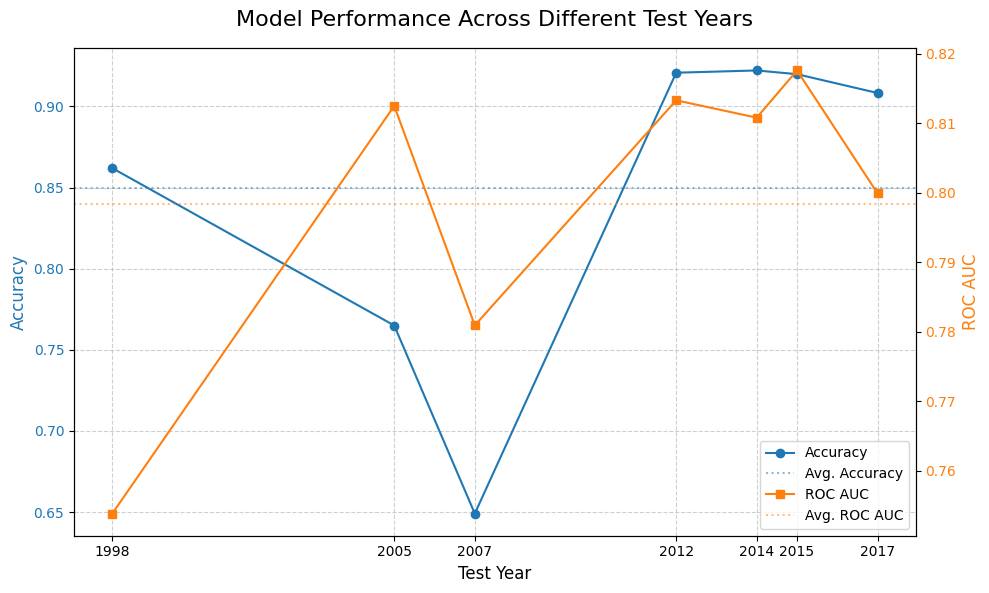

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Data provided by the user
data = {
    'Test Year': [1998, 2005, 2007, 2012, 2014, 2015, 2017],
    'Accuracy': [0.8620, 0.7650, 0.6491, 0.9208, 0.9222, 0.9199, 0.9083],
    'ROC AUC': [0.7538, 0.8125, 0.7809, 0.8133, 0.8108, 0.8176, 0.7999],
    'Dataset Size (Rows)': [35210, 81969, 85161, 37992, 46402, 51229, 46417]
}
df = pd.DataFrame(data)

# Ensure Test Year is treated as a chronological variable
df = df.sort_values(by='Test Year').reset_index(drop=True)

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 6))
fig.suptitle('Model Performance Across Different Test Years', fontsize=16)

color_acc = 'tab:blue'
ax1.set_xlabel('Test Year', fontsize=12)
ax1.set_ylabel('Accuracy', color=color_acc, fontsize=12)
ax1.plot(df['Test Year'], df['Accuracy'], color=color_acc, marker='o', label='Accuracy')
ax1.tick_params(axis='y', labelcolor=color_acc)
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a second y-axis for ROC AUC
ax2 = ax1.twinx()
color_auc = 'tab:orange'
ax2.set_ylabel('ROC AUC', color=color_auc, fontsize=12)
ax2.plot(df['Test Year'], df['ROC AUC'], color=color_auc, marker='s', label='ROC AUC')
ax2.tick_params(axis='y', labelcolor=color_auc)

# Add horizontal lines for reference (optional, but helpful for context)
ax1.axhline(df['Accuracy'].mean(), color=color_acc, linestyle=':', alpha=0.5, label='Avg. Accuracy')
ax2.axhline(df['ROC AUC'].mean(), color=color_auc, linestyle=':', alpha=0.5, label='Avg. ROC AUC')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='lower right')

# Set x-ticks to only show the years present in the data
plt.xticks(df['Test Year'])

plt.tight_layout()
print("model_performance_vs_year.png")


--- Sensitivity Analysis Summary for Year 2007 (Baseline AUC: 0.7954) ---
Optimal F1-Score Threshold: 0.250
   Accuracy: 0.7170
   Recall (Detection Rate): 0.8307

--- Sensitivity Analysis Summary for Year 2014 (Baseline AUC: 0.8287) ---
Optimal F1-Score Threshold: 0.410
   Accuracy: 0.9142
   Recall (Detection Rate): 0.4829
threshold_sensitivity.png


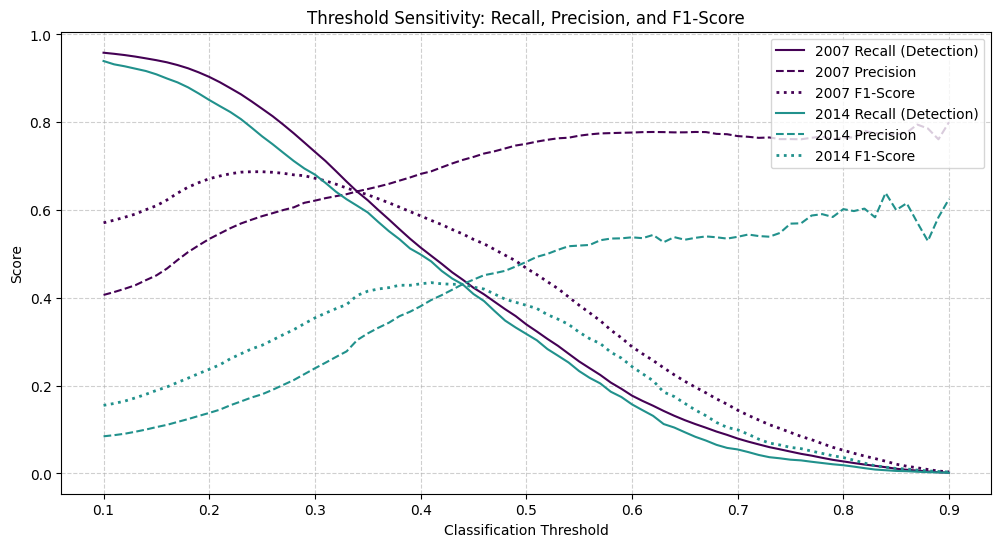

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt

# Threshold sensitivity analysis

# --- 1. Define Model Parameters and Coefficients (from 2008 training) ---

# loan_df = pd.read_csv("cleaned_loans_data.csv", low_memory=False)

relevant_cols = [
    "BorrState", "BankName", "ProcessingMethod", "Subprogram",
    "InitialInterestRate", "FixedorVariableInterestRate", "FranchiseName",
    "BusinessType", "BusinessAge", "RevolverStatus", "CollateralInd",
    "SoldSecondMarketInd", "NAICS2", "Log_GrossApproval", "Log_JobsSupported",
    "TerminMonths_Capped", "ApprovalYear"
]
target_col = "is_default"
low_p = 0.01

selected_features_names = [
    'Log_GrossApproval', 'Log_JobsSupported', 'TerminMonths_Capped',
    'BorrState_CA', 'BorrState_FL', 'BankName_Capital One, National Association',
    'BankName_KeyBank National Association', 'BankName_Manufacturers and Traders Trust Company',
    'BankName_Mountain America FCU', 'BankName_Other', 'BankName_Popular Bank',
    'BankName_VelocitySBA, LLC', 'ProcessingMethod_Community Express',
    'Subprogram_Guaranty', 'SoldSecondMarketInd_Y', 'NAICS2_33',
    'NAICS2_62', 'NAICS2_72'
]

# Coefficients (params) from the GLM fitted on 2008 training data
coefficients = pd.Series({
    'const': -2.3338, 'Log_GrossApproval': 0.2913, 'Log_JobsSupported': -0.1063,
    'TerminMonths_Capped': -0.0252, 'BorrState_CA': 0.2551, 'BorrState_FL': 0.6136,
    'BankName_Capital One, National Association': 1.0551,
    'BankName_KeyBank National Association': -0.6606,
    'BankName_Manufacturers and Traders Trust Company': -0.9173,
    'BankName_Mountain America FCU': 0.7189, 'BankName_Other': -0.6601,
    'BankName_Popular Bank': 0.9250, 'BankName_VelocitySBA, LLC': 0.7057,
    'ProcessingMethod_Community Express': 0.5594, 'Subprogram_Guaranty': 0.6426,
    'SoldSecondMarketInd_Y': 0.8495, 'NAICS2_33': -0.3916,
    'NAICS2_62': -0.5022, 'NAICS2_72': 0.2803
})


# --- 2. Data Processing and Prediction Function ---

def get_processed_data(df, year_filter, relevant_cols, selected_features_names, coefficients, low_p):
    """Filters data, applies preprocessing, aligns features, and returns y_true and y_pred_prob."""
    df_year = df[df["ApprovalYear"].isin(year_filter)].copy()

    if df_year.empty:
        return None, None

    X_year = df_year[relevant_cols].copy()
    y_true = df_year[target_col].copy()

    # Preprocessing (Replicating notebook steps for 2007 and 2014)
    for cat_col in X_year.select_dtypes(include=['object', 'category']).columns:
        if X_year[cat_col].isnull().any():
            X_year[cat_col] = X_year[cat_col].fillna("Missing")

        top = X_year[cat_col].value_counts(normalize=True)
        top_names = top[top >= low_p].index
        X_year.loc[~X_year[cat_col].isin(top_names), cat_col] = "Other"

    # One-Hot Encoding and Alignment
    X_year_encoded = pd.get_dummies(X_year, drop_first=True, dtype=np.uint8)

    # Simple feature name adaptation used in the previous successful runs
    # This is necessary because OHE columns might contain spaces/commas,
    # which we assume were properly handled during the original 2008 fitting.
    feature_columns = ['const'] + selected_features_names

    X_year_aligned = X_year_encoded.reindex(columns=selected_features_names, fill_value=0)
    X_year_sm = X_year_aligned.copy()
    X_year_sm.insert(0, 'const', 1)
    X_year_sm = X_year_sm[feature_columns]

    # Prediction
    eta = X_year_sm.dot(coefficients)
    y_pred_prob = 1 / (1 + np.exp(-eta))

    return y_true, y_pred_prob


# --- 3. Threshold Analysis Function ---

def calculate_metrics_at_threshold(y_true, y_pred_prob, threshold):
    """Calculates classification metrics at a given threshold."""
    y_pred = (y_pred_prob >= threshold).astype(int)

    # Handle the case where the predicted class is entirely one label,
    # which can cause precision/recall to fail if zero division occurs.
    # We use zero_division=0 to suppress the warning and set the score to 0.0
    return {
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_true, y_pred),
        # Precision: Out of all predicted positives, how many are true positives?
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        # Recall: Out of all true positives, how many did we catch? (Default Detection Rate)
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    }

# --- 4. Main Execution (Placeholder for data loading) ---

# *** REMEMBER TO LOAD YOUR loan_df HERE BEFORE RUNNING ***
# loan_df = pd.read_csv("cleaned_loans_data.csv", low_memory=False)
# ---

# Define threshold range
thresholds = np.linspace(0.1, 0.9, 81) # 0.10, 0.11, ..., 0.90

test_years = [2007, 2014]
results_dfs = {}

for year in test_years:
    try:
        # Assuming loan_df is loaded at the top
        y_true, y_pred_prob = get_processed_data(loan_df, [year], relevant_cols, selected_features_names, coefficients, low_p)

        if y_true is None:
            print(f"Skipping year {year} due to lack of data.")
            continue

        metrics = [calculate_metrics_at_threshold(y_true, y_pred_prob, t) for t in thresholds]
        results_df = pd.DataFrame(metrics)
        results_dfs[year] = results_df

        # Print summary of the analysis for the year
        print(f"\n--- Sensitivity Analysis Summary for Year {year} (Baseline AUC: {roc_auc_score(y_true, y_pred_prob):.4f}) ---")

        # Find threshold that maximizes F1-Score
        optimal_f1_row = results_df.loc[results_df['F1-Score'].idxmax()]
        print(f"Optimal F1-Score Threshold: {optimal_f1_row['Threshold']:.3f}")
        print(f"   Accuracy: {optimal_f1_row['Accuracy']:.4f}")
        print(f"   Recall (Detection Rate): {optimal_f1_row['Recall']:.4f}")

    except NameError:
        print("Error: loan_df is not loaded. Cannot run sensitivity analysis.")
        break
    except Exception as e:
        print(f"An error occurred while processing year {year}: {e}")
        break


# --- 5. Plotting ---

if results_dfs:
    plt.figure(figsize=(12, 6))

    for i, year in enumerate(test_years):
        df_plot = results_dfs[year]
        color = plt.cm.viridis(i / (len(test_years)))

        # Plot Recall (Detection Rate)
        plt.plot(df_plot['Threshold'], df_plot['Recall'],
                 label=f'{year} Recall (Detection)', linestyle='-', color=color)

        # Plot Precision
        plt.plot(df_plot['Threshold'], df_plot['Precision'],
                 label=f'{year} Precision', linestyle='--', color=color)

        # Plot F1-Score (for finding the balance)
        plt.plot(df_plot['Threshold'], df_plot['F1-Score'],
                 label=f'{year} F1-Score', linestyle=':', color=color, linewidth=2)

    plt.title('Threshold Sensitivity: Recall, Precision, and F1-Score')
    plt.xlabel('Classification Threshold')
    plt.ylabel('Score')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig('threshold_sensitivity.png')
    print("threshold_sensitivity.png")